In [139]:
import jax.numpy as jnp
import jax

# Now plotting the things
import matplotlib.pyplot as plt
from mGST.utility_functions_comparisons import kraus_tensor_to_mgst, povm_psd_to_mgst, state_psd_to_mgst
from mGST.low_level_jit import contract_mps_general_povm, contract_mps_abstract_povm_coherent
from mGST.automatic_diff import automatic_gradient, hvp
from mGST.visualization import plot_wall_time, plot_many_sets_wall_time

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [56]:
key = jax.random.PRNGKey(42)
def generate_random_instance(num_gates:int, num_qubits:int, rank_kraus:int, povm_rank:int = None, state_rank:int = None, depth:int = None):
    dim = 2**num_qubits
    if povm_rank is None:
        povm_rank = dim
    if state_rank is None:
        state_rank = dim
    if depth is None:
        depth = num_gates # Probably not a realistic assumption, but it's good enough for our purposes for timing functions.
        
    # Complex random tensors
    povm_rnd_tensor =  jax.random.uniform(key, shape=(1, povm_rank, dim)) + 1j * jax.random.uniform(key, shape=(1, povm_rank, dim)) # (num_povm, rank_povm, dim)
    kraus_rnd_tensor = jax.random.uniform(key, shape=(num_gates, rank_kraus, dim, dim)) + 1j * jax.random.uniform(key, shape=(num_gates, rank_kraus, dim, dim)) # (num_gates, kraus_rank, dim_out, dim_in)
    state_rnd_tensor = jax.random.uniform(key, shape=(dim, state_rank)) + 1j * jax.random.uniform(key, shape=(dim, state_rank)) # (dim, rank_state)
    gates_sequences_rnd = jax.random.randint(key, shape=(depth, ), minval=0, maxval=num_gates)
    return {"kraus_tensor": kraus_rnd_tensor, "povm_psd": povm_rnd_tensor, "state_psd": state_rnd_tensor, "gates_indices": gates_sequences_rnd}

def contract(X, j_vec):
    """Contract a sequence of matrices in the given order.
    
    Implementation from mGST.low_level_jit without the j_vec processing
    """
    res = jnp.eye(X[0].shape[0])
    res = res.astype(jnp.complex128)
    for j in j_vec:
        res = res.dot(X[j])
    return res

def contract_naive(kraus_tensor, povm_psd, state_psd, gates_indices):
    """
    Contraction path that creates first a big tensor for the gates and then contracts it with the state and povm.
    
    It is expected that this cost function scales as O((2^N)^8).
    """
    state_rnd_vect = state_psd_to_mgst(state_psd=state_psd)
    povm_rnd_vect = povm_psd_to_mgst(povm_psd=povm_psd)[0] # we take the first one since we only have one povm element
    superop = kraus_tensor_to_mgst(kraus_tensor=kraus_tensor)
    full_gates_superop = contract(superop, gates_indices)
    return povm_rnd_vect.conj() @ full_gates_superop @ state_rnd_vect

# Data generation
* number of gates = 5
* kraus rank = 4
* state rank = povm rank = dim = 2^num_qubits

In [3]:
num_gates = 5
rank_kraus = 1

In [4]:
all_num_qubits = jnp.arange(1, 10)

all_tensors = []

for qubits in all_num_qubits:

    tensors = generate_random_instance(num_gates, qubits, rank_kraus)
    all_tensors.append(tensors)

    if qubits <= 6: # for more than 6 qubits the naive contraction takes too long
        cost_mgst = contract_naive(**tensors)

        cost_mps = contract_mps_general_povm(**tensors)

        print(jnp.allclose(cost_mgst, cost_mps))

True
True
True
True
True
True


In [12]:
# testing for the coherent one if they are all the same with the general mps cost
for tensors in all_tensors:
    cost_mps_general = contract_mps_general_povm(**tensors)
    cost_mps_coherent = contract_mps_abstract_povm_coherent(**tensors)
    print(jnp.allclose(cost_mps_general, cost_mps_coherent))

True
True
True
True
True
True
True
True
True


In [7]:
all_tensors[0]["kraus_tensor"].shape

(5, 1, 2, 2)

# Timing

In [5]:
timing_cost_1q_naive = %timeit -o contract_naive(**all_tensors[0])
timing_cost_2q_naive = %timeit -o contract_naive(**all_tensors[1])
timing_cost_3q_naive = %timeit -o contract_naive(**all_tensors[2])
timing_cost_4q_naive = %timeit -o contract_naive(**all_tensors[3])
timing_cost_5q_naive = %timeit -o contract_naive(**all_tensors[4])

1.17 ms ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.27 ms ± 4.78 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.49 ms ± 4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
7.74 ms ± 435 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
264 ms ± 3.89 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
timing_cost_1q_mps = %timeit -o contract_mps_general_povm(**all_tensors[0])
timing_cost_2q_mps = %timeit -o contract_mps_general_povm(**all_tensors[1])
timing_cost_3q_mps = %timeit -o contract_mps_general_povm(**all_tensors[2])
timing_cost_4q_mps = %timeit -o contract_mps_general_povm(**all_tensors[3])
timing_cost_5q_mps = %timeit -o contract_mps_general_povm(**all_tensors[4])

1.74 ms ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.8 ms ± 50.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.89 ms ± 43.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.92 ms ± 26.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.19 ms ± 454 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
timing_cost_6q_mps = %timeit -o contract_mps_general_povm(**all_tensors[5])
timing_cost_7q_mps = %timeit -o contract_mps_general_povm(**all_tensors[6])
timing_cost_8q_mps = %timeit -o contract_mps_general_povm(**all_tensors[7])
timing_cost_9q_mps = %timeit -o contract_mps_general_povm(**all_tensors[8])

2.09 ms ± 10.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3.91 ms ± 190 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
16.3 ms ± 269 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
93 ms ± 3.35 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
timing_cost_1q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[0])
timing_cost_2q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[1])
timing_cost_3q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[2])
timing_cost_4q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[3])
timing_cost_5q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[4])

1.05 ms ± 17.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.05 ms ± 6.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.1 ms ± 6.94 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.09 ms ± 3.41 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.14 ms ± 6.15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [17]:
timing_cost_6q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[5])
timing_cost_7q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[6])
timing_cost_8q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[7])
timing_cost_9q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[8])

1.26 ms ± 16.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.01 ms ± 48 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
8.11 ms ± 16.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
45.2 ms ± 210 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Gathering data

In [49]:
timings_naive = [timing_cost_1q_naive, timing_cost_2q_naive, timing_cost_3q_naive, timing_cost_4q_naive, timing_cost_5q_naive]
timings_mps = [timing_cost_1q_mps, timing_cost_2q_mps, timing_cost_3q_mps, timing_cost_4q_mps, timing_cost_5q_mps, timing_cost_6q_mps, timing_cost_7q_mps, timing_cost_8q_mps, timing_cost_9q_mps]
timings_mps_coherent = [timing_cost_1q_mps_coherent, timing_cost_2q_mps_coherent, timing_cost_3q_mps_coherent, timing_cost_4q_mps_coherent, timing_cost_5q_mps_coherent, timing_cost_6q_mps_coherent, timing_cost_7q_mps_coherent, timing_cost_8q_mps_coherent, timing_cost_9q_mps_coherent]

tuples_naive = [(time.average, time.stdev) for time in timings_naive]
tuples_mps = [(time.average, time.stdev) for time in timings_mps]
tuples_mps_coherent = [(time.average, time.stdev) for time in timings_mps_coherent]

cost_fn_times = {
    r"Brieger et al.": tuples_naive,
    r"MPS (incoherent)": tuples_mps,
    r"MPS (coherent)": tuples_mps_coherent
}

# Plotting

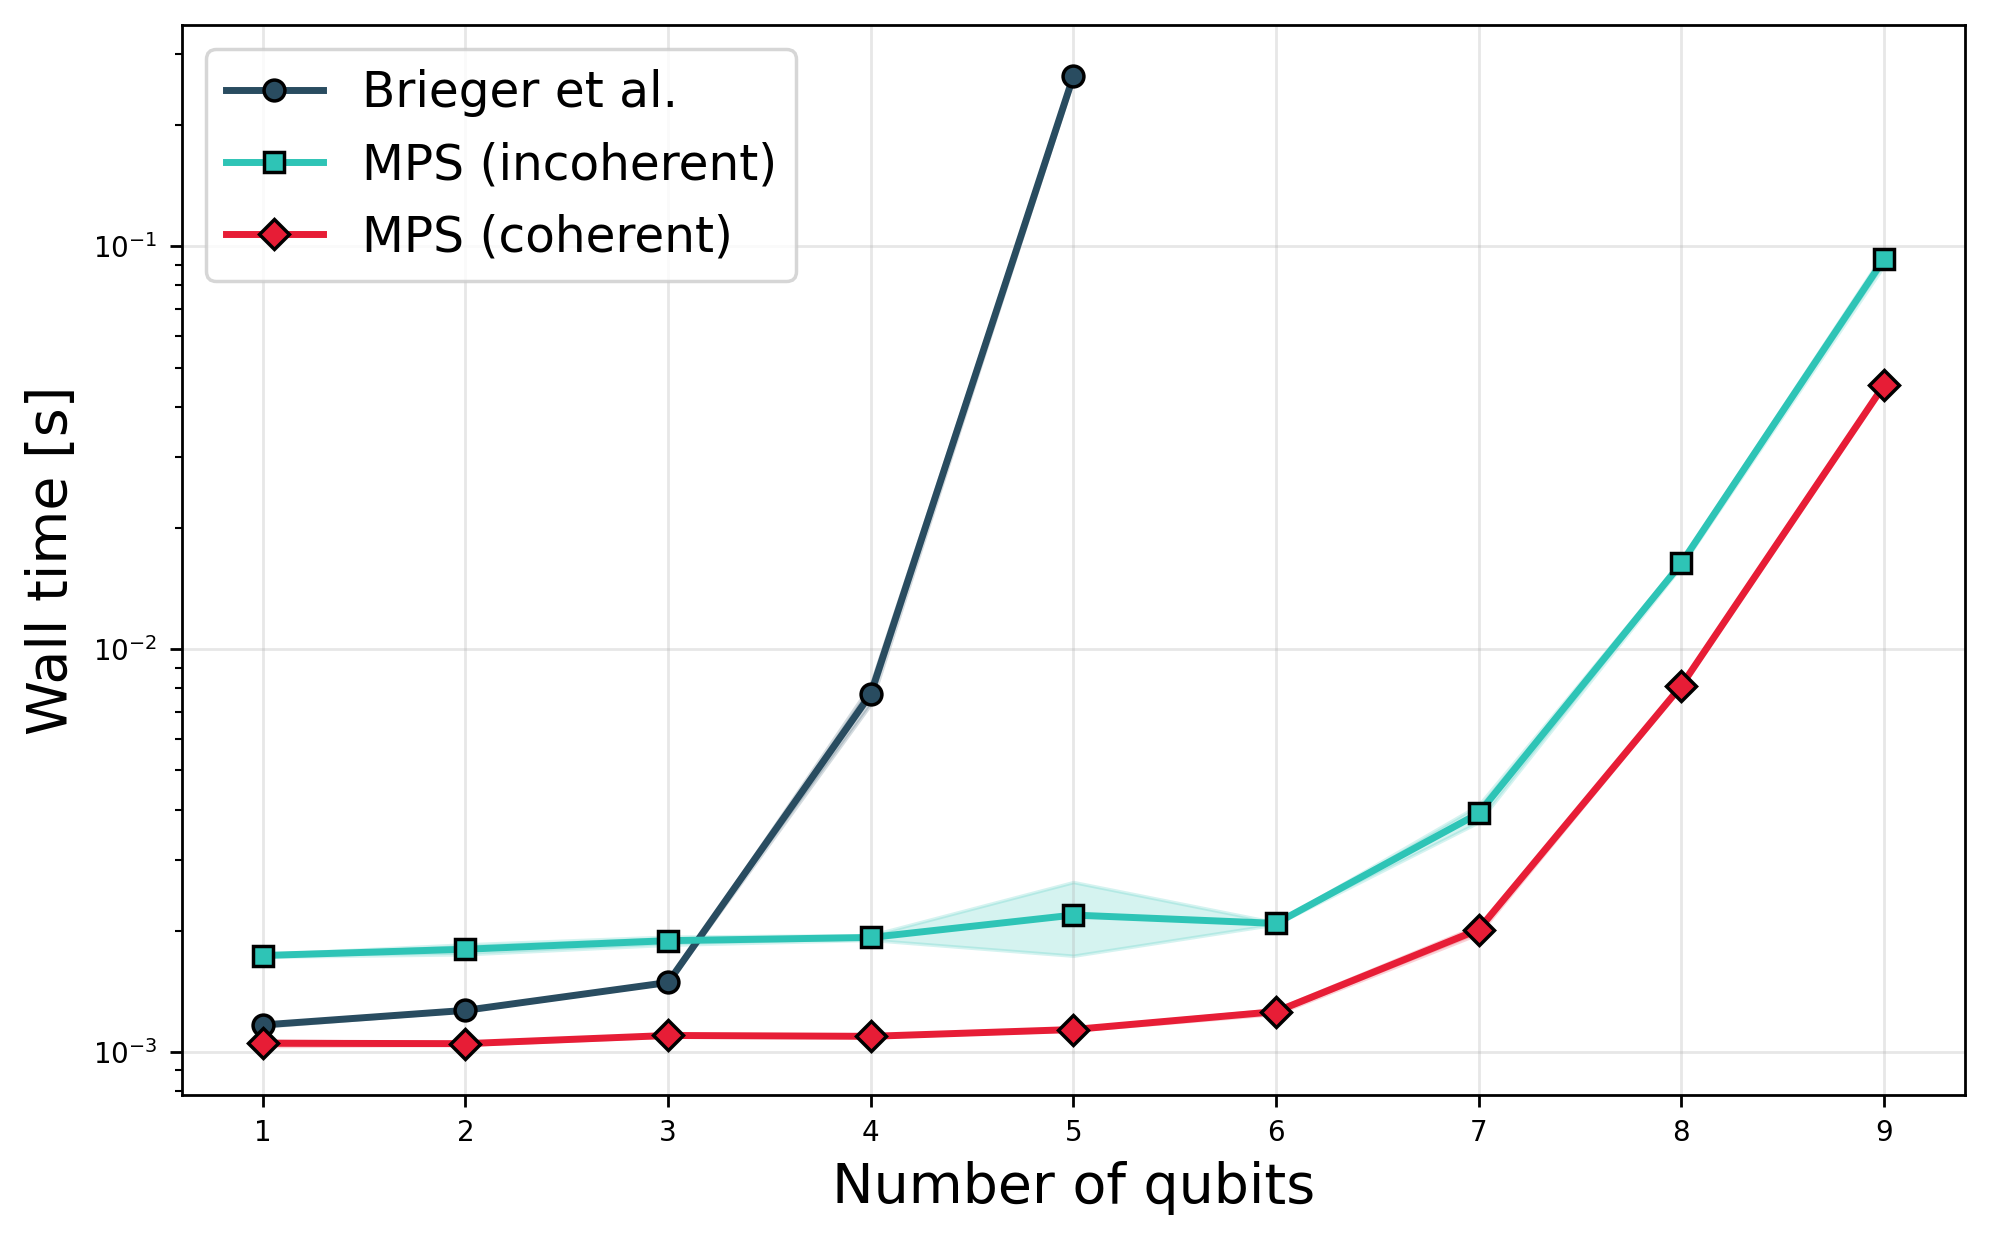

In [148]:
plot_wall_time(time_data=cost_fn_times, x_values=all_num_qubits, logscale="y", title=None, different_lengths_allowed=True, label_fontsize=16, legend_fontsize=14, legend_loc="upper left")

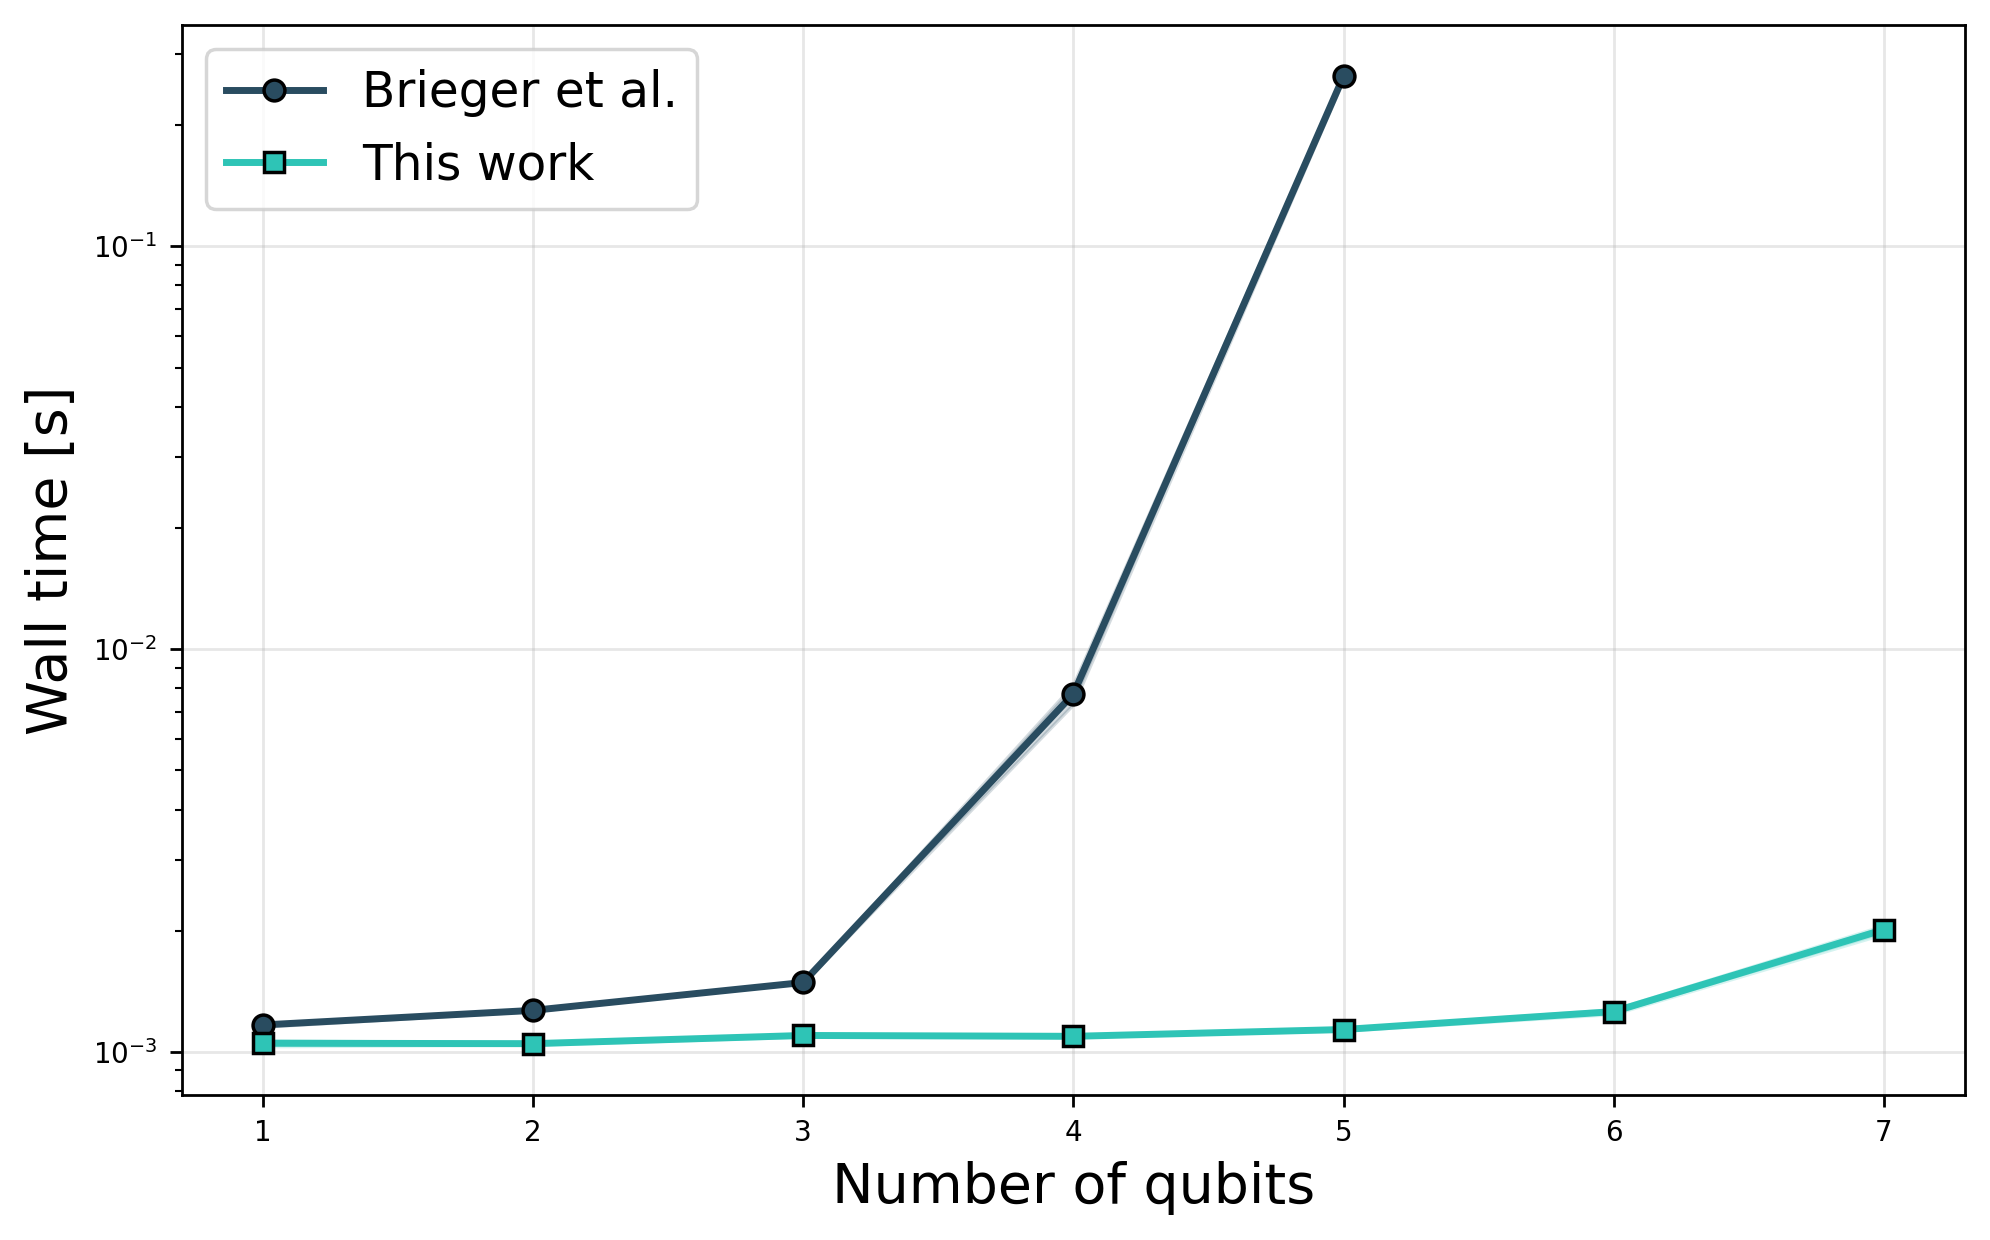

In [147]:
cost_fn_times_intro = {
    r"Brieger et al.": tuples_naive,
    r"This work": tuples_mps_coherent[:7]
}
plot_wall_time(time_data=cost_fn_times_intro, x_values=all_num_qubits, logscale="y", title=None, different_lengths_allowed=True, label_fontsize=16, legend_fontsize=14, legend_loc="upper left")

## Extra (old) plot

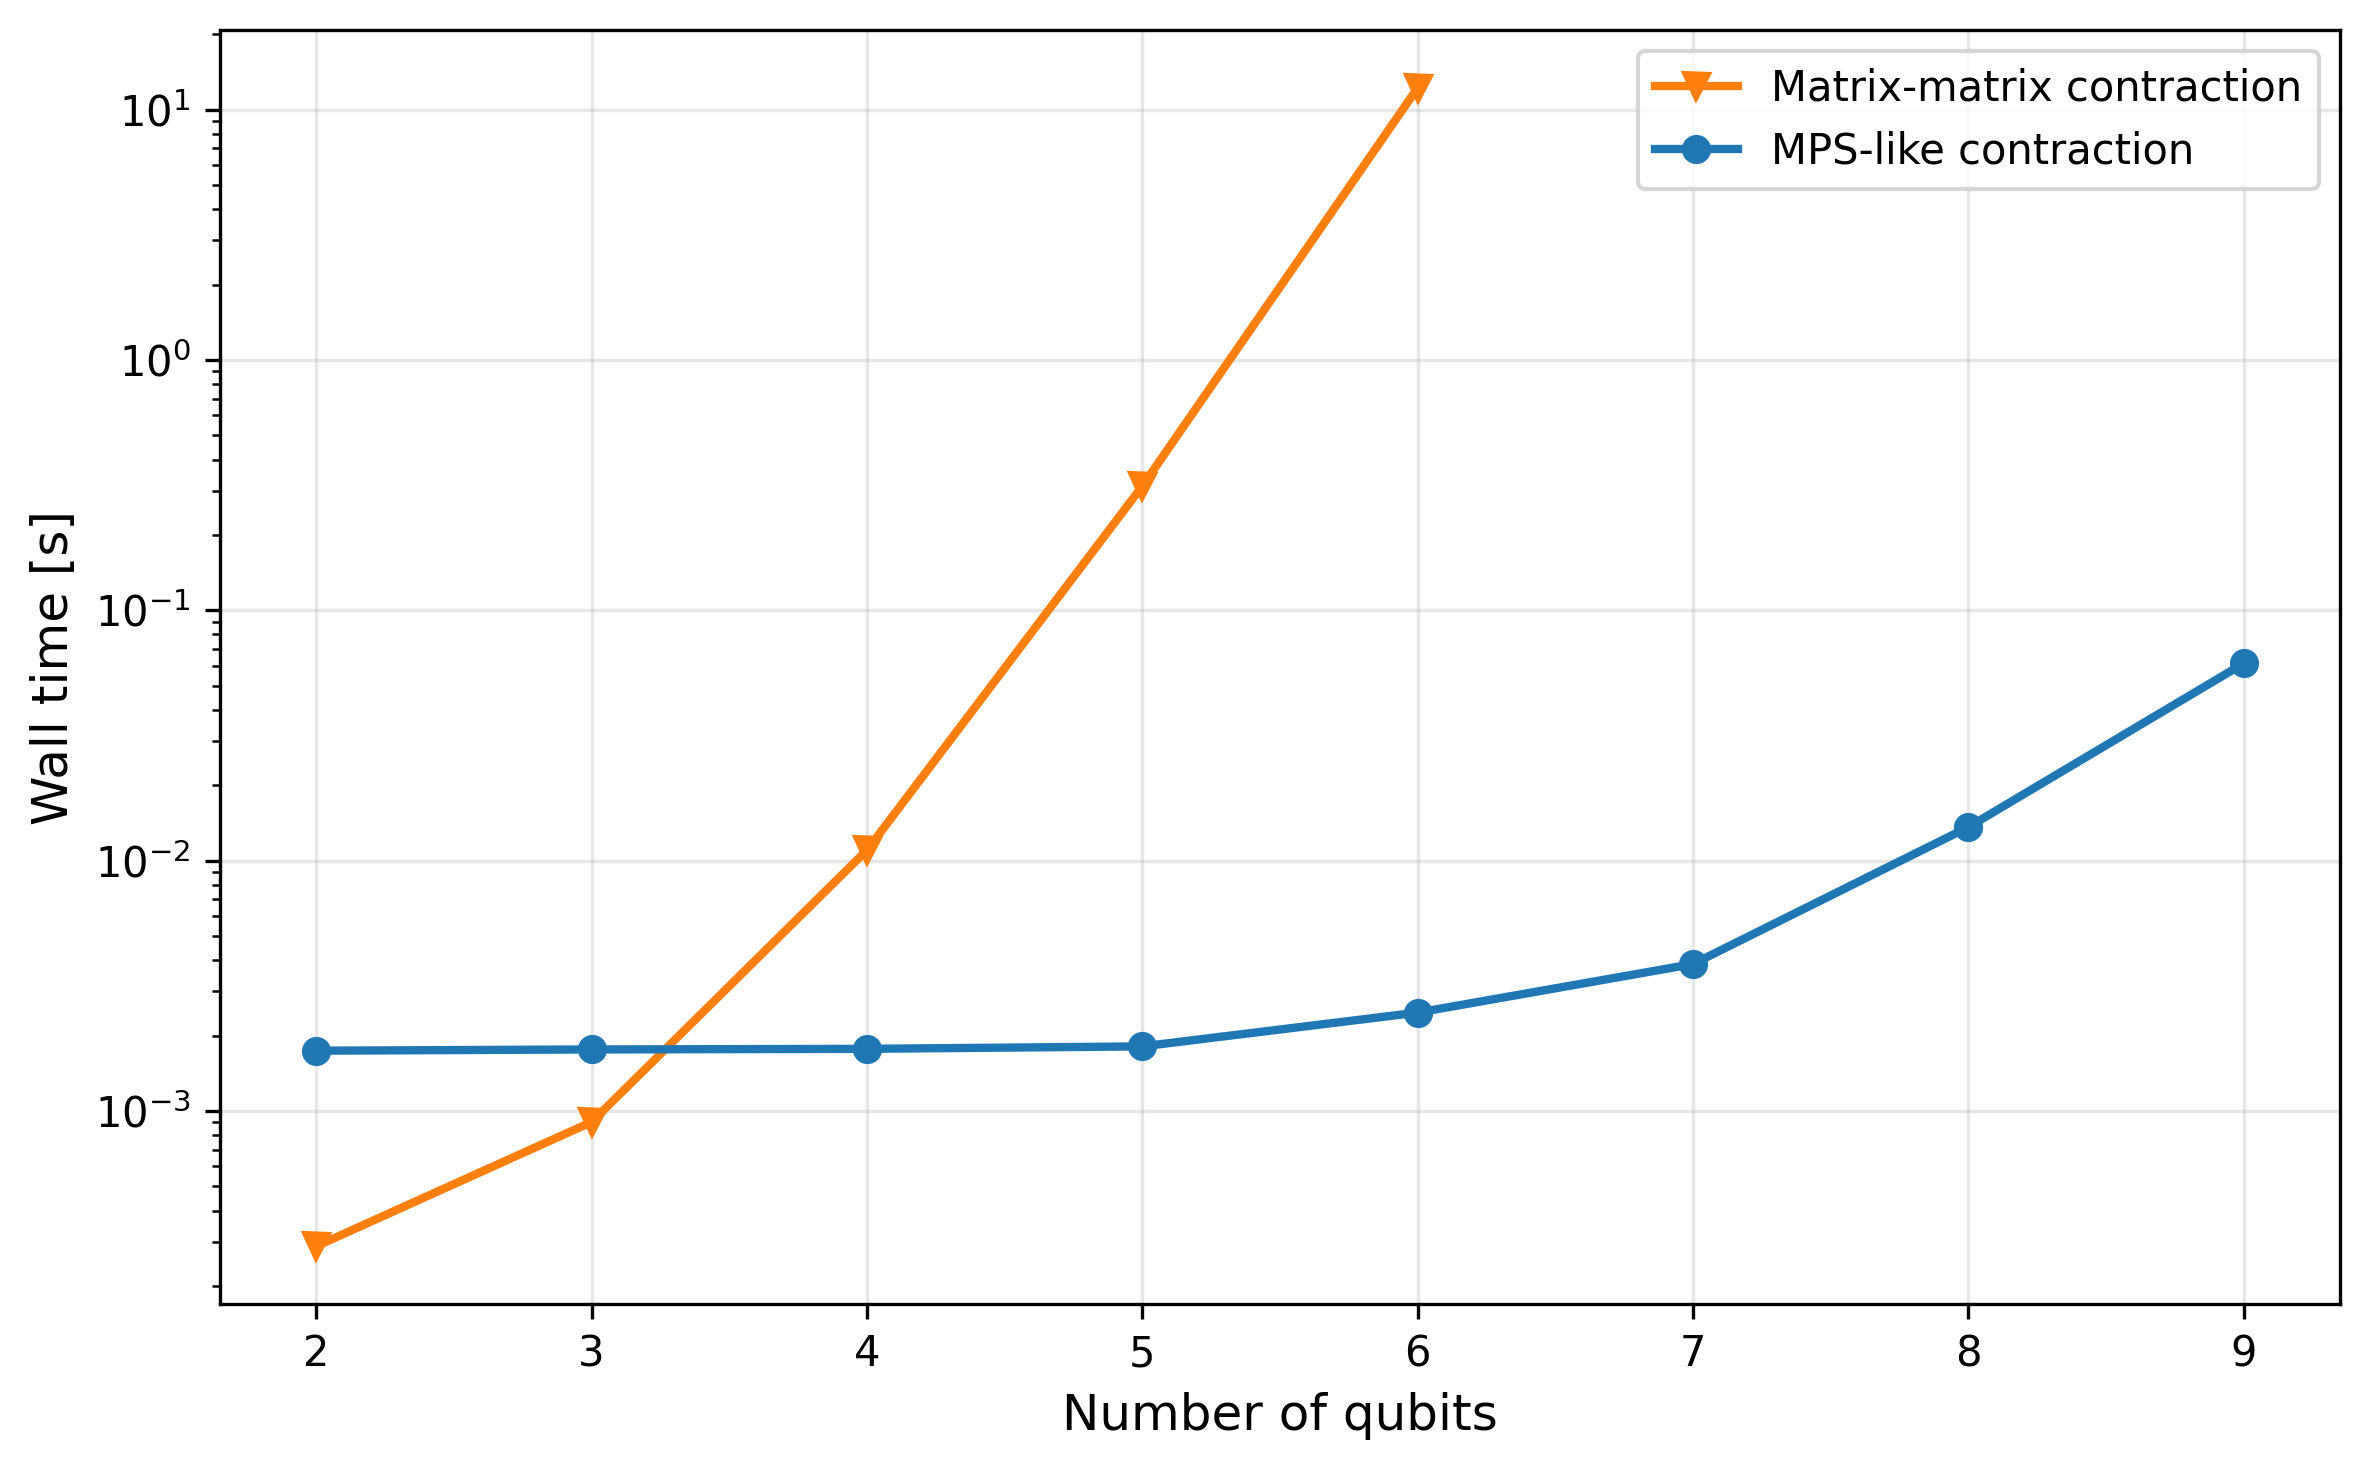

In [ ]:
# Create the plot. From notebook: gst_contraction_comparison.ipynb
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 6

times_naive = jnp.array([288e-6, 903e-6, 11e-3, 313e-3, 12.2])
times_mps_opt_path= jnp.array([1.74, 1.76, 1.77, 1.81, 2.47, 3.86, 13.6, 61.3])/1000


plt.semilogy(range(2, max_num_qubits+1), times_naive, label="Matrix-matrix contraction", color="#ff7f0e", linestyle="-", marker="v", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+4), times_mps_opt_path, label="MPS-like contraction", color="#1f77b4", linestyle="-", marker="o", linewidth=2, markersize=6)


# Add labels, legend, and grid
plt.xlabel("Number of qubits", fontsize=12)
plt.ylabel("Wall time [s]", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Cost fn vs Gradient vs Hvp

## Kraus rank (does not show linear scaling)

In [38]:
# First let's compute a set of data for which we know the cost function should increase linearly
num_qubits_fixed = 2
dim_fixed = 2**num_qubits_fixed
num_gates_fixed = 5
state_rank = 1
povm_rank = 1

rank_kraus_list = jnp.arange(1, dim_fixed**2+1) # kraus dimension can be at most dim^2
tensors_rank_kraus = []
for rank in rank_kraus_list:
    tensors = generate_random_instance(num_gates=num_gates_fixed, num_qubits=num_qubits_fixed, rank_kraus=rank, povm_rank=povm_rank, state_rank=state_rank)
    tensors_rank_kraus.append(tensors)

In [57]:
rank_kraus_list, len(tensors_rank_kraus),[op.shape for op in tensors_rank_kraus[-1].values()], [op.shape for op in tensors_rank_kraus[0].values()]

(Array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],      dtype=int64),
 16,
 [(5, 16, 4, 4), (1, 1, 4), (4, 1), (5,)],
 [(5, 1, 4, 4), (1, 1, 4), (4, 1), (5,)])

### Timing

In [44]:
timing_cost_rank1 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[0])
timing_cost_rank2 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[1])
timing_cost_rank3 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[2])
timing_cost_rank4 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[3])

1.73 ms ± 13.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.72 ms ± 7.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.73 ms ± 5.53 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.78 ms ± 3.24 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [46]:
timing_cost_rank5 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[4])
timing_cost_rank6 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[5])
timing_cost_rank7 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[6])
timing_cost_rank8 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[7])
timing_cost_rank9 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[8])
timing_cost_rank10 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[9])
timing_cost_rank11 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[10])
timing_cost_rank12 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[11])
timing_cost_rank13 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[12])
timing_cost_rank14 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[13])
timing_cost_rank15 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[14])
timing_cost_rank16 = %timeit -o contract_mps_general_povm(**tensors_rank_kraus[15])

1.77 ms ± 22.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.87 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.77 ms ± 25.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.79 ms ± 7.81 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.79 ms ± 7.95 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.81 ms ± 48.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.79 ms ± 15.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.78 ms ± 21.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.81 ms ± 47.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.79 ms ± 20.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.79 ms ± 6.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.82 ms ± 19.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Plotting

In [63]:
timings_ranks = [timing_cost_rank1, timing_cost_rank2, timing_cost_rank3, timing_cost_rank4, timing_cost_rank5, timing_cost_rank6, timing_cost_rank7, timing_cost_rank8, timing_cost_rank9, timing_cost_rank10, timing_cost_rank11, timing_cost_rank12, timing_cost_rank13, timing_cost_rank14, timing_cost_rank15, timing_cost_rank16]

tuples_ranks = [(time.average, time.stdev) for time in timings_ranks]

cost_fn_times_ranks = {
    r"MPS (ranks)": tuples_ranks}

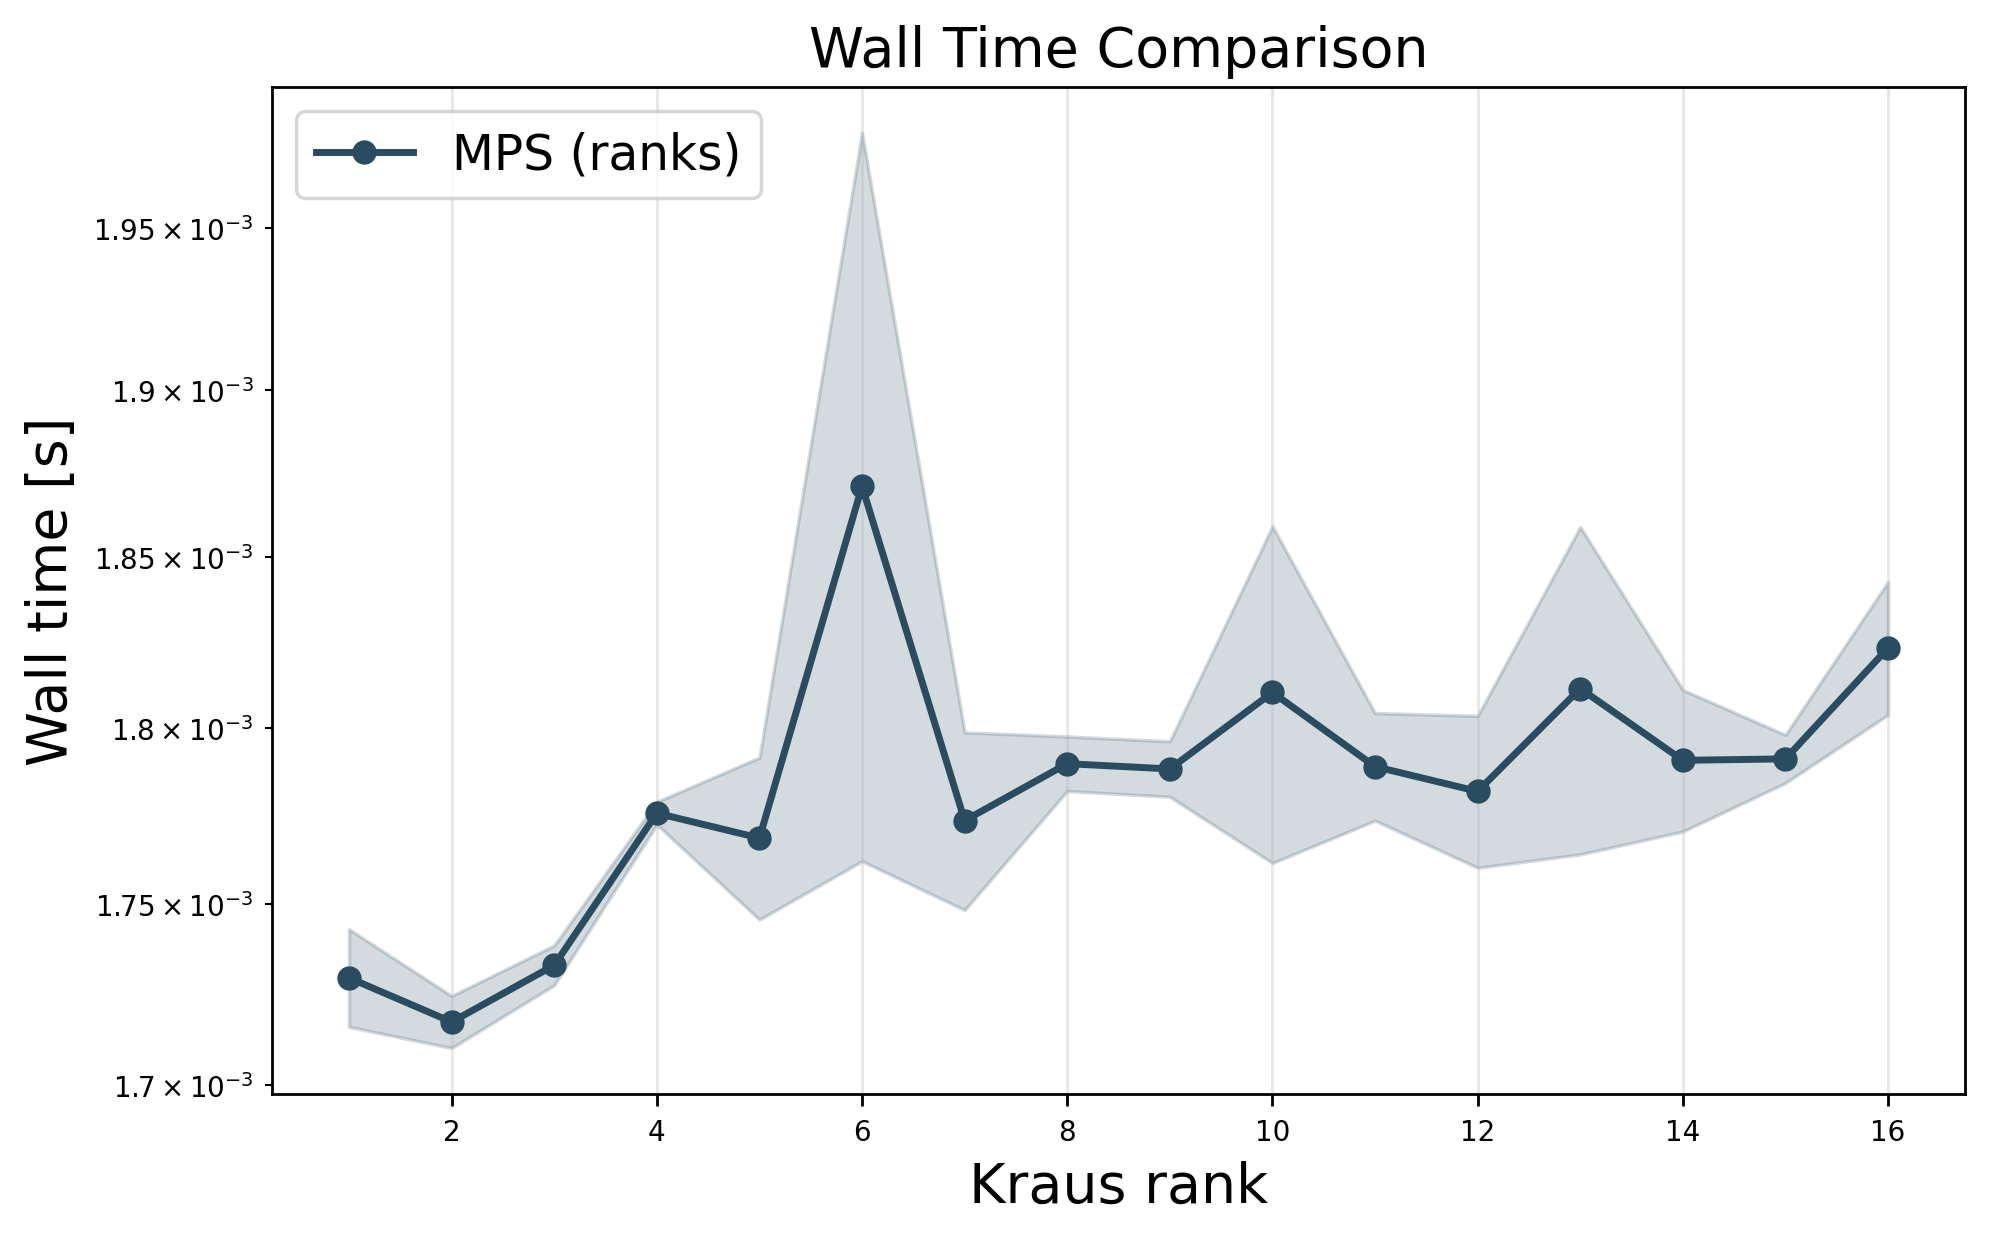

In [52]:
plot_wall_time(
    time_data=cost_fn_times_ranks, 
    x_values=rank_kraus_list,
    xlabel="Kraus rank", 
    logscale="y", 
    label_fontsize=16, 
    legend_fontsize=14, 
    legend_loc="upper left"
)

## Depth of sequences

### Data generation

In [58]:
# First let's compute a set of data for which we know the cost function should increase linearly
num_qubits_fixed = 2
dim_fixed = 2**num_qubits_fixed
num_gates_fixed = 5
state_rank = 1
povm_rank = 1
kraus_rank_fixed = dim_fixed**2

depth_list = jnp.arange(5, 31, 5) # kraus dimension can be at most dim^2
tensors_depths = []
for depth in depth_list:
    tensors = generate_random_instance(num_gates=num_gates_fixed, num_qubits=num_qubits_fixed, rank_kraus=kraus_rank_fixed, povm_rank=povm_rank, state_rank=state_rank, depth=depth)
    tensors_depths.append(tensors)
    
print(len(tensors_depths))

6


In [69]:
print(depth_list)
[op.shape for op in tensors_depths[0].values()], [op.shape for op in tensors_depths[-1].values()]

[ 5 10 15 20 25 30]


([(5, 16, 4, 4), (1, 1, 4), (4, 1), (5,)],
 [(5, 16, 4, 4), (1, 1, 4), (4, 1), (30,)])

In [116]:
# Let's create a function for each depth, differentiating against Kraus
povm_psd = tensors_depths[0]["povm_psd"]
state_psd = tensors_depths[0]["state_psd"]
cost_fn_depth_5 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[0]["gates_indices"]).sum().real

cost_fn_depth_10 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[1]["gates_indices"]).sum().real

cost_fn_depth_15 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[2]["gates_indices"]).sum().real

cost_fn_depth_20 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[3]["gates_indices"]).sum().real

cost_fn_depth_25 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[4]["gates_indices"]).sum().real

cost_fn_depth_30 = lambda x: contract_mps_general_povm(kraus_tensor=x, povm_psd=povm_psd, state_psd=state_psd, gates_indices=tensors_depths[5]["gates_indices"]).sum().real

In [81]:
grad_fn_depth_5 = automatic_gradient(cost_fn_depth_5)
grad_fn_depth_10 = automatic_gradient(cost_fn_depth_10)
grad_fn_depth_15 = automatic_gradient(cost_fn_depth_15)
grad_fn_depth_20 = automatic_gradient(cost_fn_depth_20)
grad_fn_depth_25 = automatic_gradient(cost_fn_depth_25)
grad_fn_depth_30 = automatic_gradient(cost_fn_depth_30)

In [72]:
kraus_tensor_fixed = tensors_depths[0]["kraus_tensor"]

In [ ]:
cost_fn_depth_5(kraus_tensor_fixed).shape # should be a scalar for automatic gradient to work.

()

### Timing

In [61]:
timing_cost_depth0 = %timeit -o contract_mps_general_povm(**tensors_depths[0])
timing_cost_depth1 = %timeit -o contract_mps_general_povm(**tensors_depths[1])
timing_cost_depth2 = %timeit -o contract_mps_general_povm(**tensors_depths[2])
timing_cost_depth3 = %timeit -o contract_mps_general_povm(**tensors_depths[3])
timing_cost_depth4 = %timeit -o contract_mps_general_povm(**tensors_depths[4])
timing_cost_depth5 = %timeit -o contract_mps_general_povm(**tensors_depths[5])

1.82 ms ± 25.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
3.6 ms ± 228 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.21 ms ± 43.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.9 ms ± 20 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
8.83 ms ± 219 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
10.4 ms ± 173 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [82]:
timing_grad_depth0 = %timeit -o grad_fn_depth_5(kraus_tensor_fixed)
timing_grad_depth1 = %timeit -o grad_fn_depth_10(kraus_tensor_fixed)
timing_grad_depth2 = %timeit -o grad_fn_depth_15(kraus_tensor_fixed)
timing_grad_depth3 = %timeit -o grad_fn_depth_20(kraus_tensor_fixed)
timing_grad_depth4 = %timeit -o grad_fn_depth_25(kraus_tensor_fixed)
timing_grad_depth5 = %timeit -o grad_fn_depth_30(kraus_tensor_fixed)

10.7 ms ± 246 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
20.2 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
32.5 ms ± 1.39 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
42.8 ms ± 1.71 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
53.3 ms ± 2.82 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
59.5 ms ± 1.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [87]:
timing_hvp_depth0 = %timeit -o hvp(function=grad_fn_depth_5, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_depth1 = %timeit -o hvp(function=grad_fn_depth_10, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_depth2 = %timeit -o hvp(function=grad_fn_depth_15, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_depth3 = %timeit -o hvp(function=grad_fn_depth_20, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_depth4 = %timeit -o hvp(function=grad_fn_depth_25, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_depth5 = %timeit -o hvp(function=grad_fn_depth_30, x=kraus_tensor_fixed, z=kraus_tensor_fixed)

17.8 ms ± 596 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
32.5 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
46.2 ms ± 155 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
60.8 ms ± 488 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
76 ms ± 1.79 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
90 ms ± 566 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Plotting

In [112]:
timings_cost_depths = [timing_cost_depth0, timing_cost_depth1, timing_cost_depth2, timing_cost_depth3, timing_cost_depth4, timing_cost_depth5]

timings_grad_depths = [timing_grad_depth0, timing_grad_depth1, timing_grad_depth2, timing_grad_depth3, timing_grad_depth4, timing_grad_depth5]

timings_hvp_depths = [timing_hvp_depth0, timing_hvp_depth1, timing_hvp_depth2, timing_hvp_depth3, timing_hvp_depth4, timing_hvp_depth5]

tuples_cost_depths = [(time.average, time.stdev) for time in timings_cost_depths]
tuples_grads_depths = [(time.average, time.stdev) for time in timings_grad_depths]
tuples_hvp_depths = [(time.average, time.stdev) for time in timings_hvp_depths]

wall_times_depths = {
    r"Cost function": tuples_cost_depths,
    r"Gradient": tuples_grads_depths,
    r"HVP": tuples_hvp_depths}

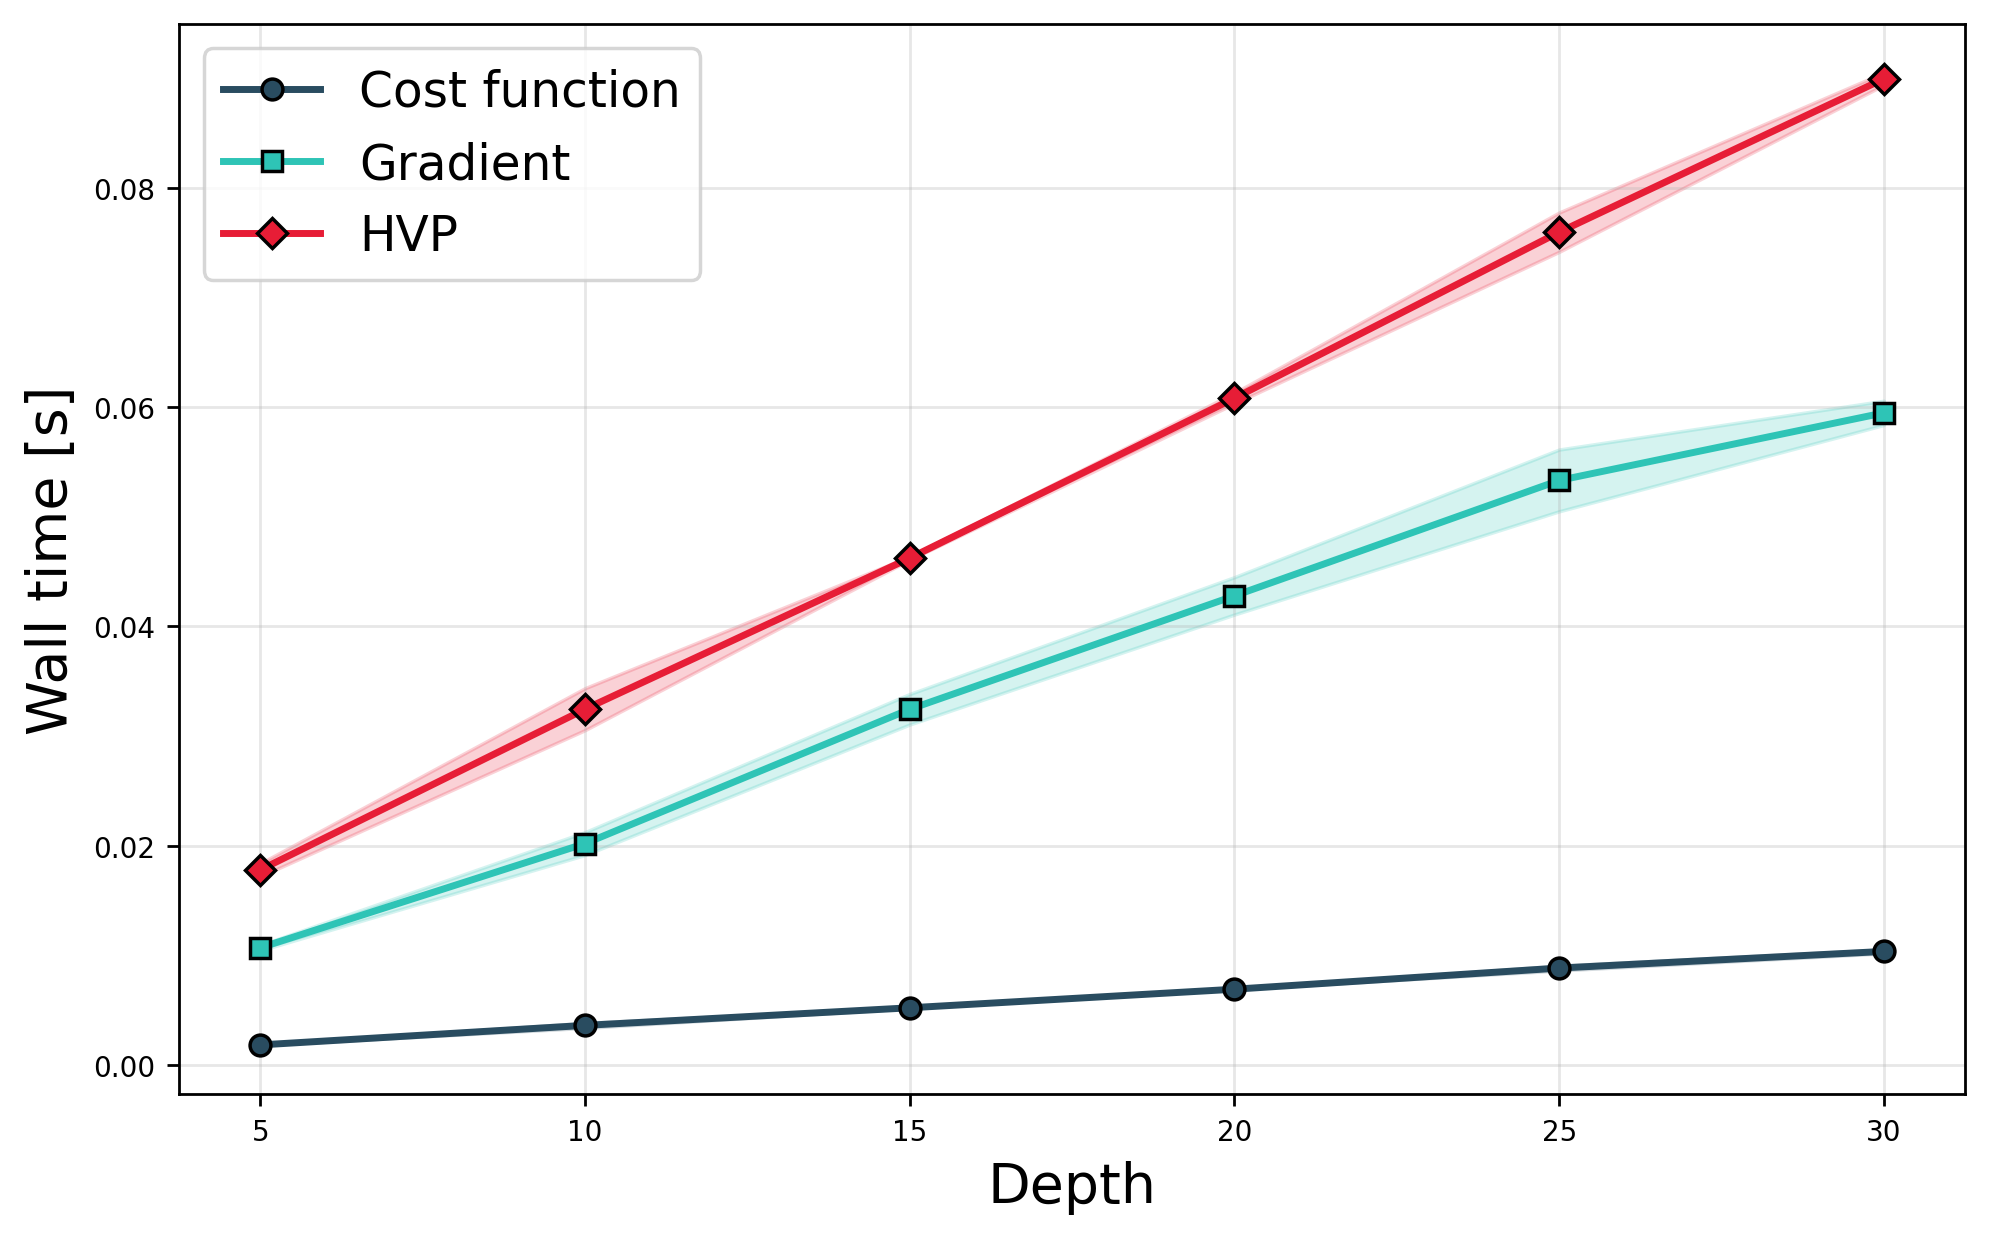

In [149]:
plot_wall_time(
    time_data=wall_times_depths, 
    x_values=depth_list,
    xlabel="Depth", 
    logscale=None,
    title=None, 
    label_fontsize=16, 
    legend_fontsize=14, 
    legend_loc="upper left"
)

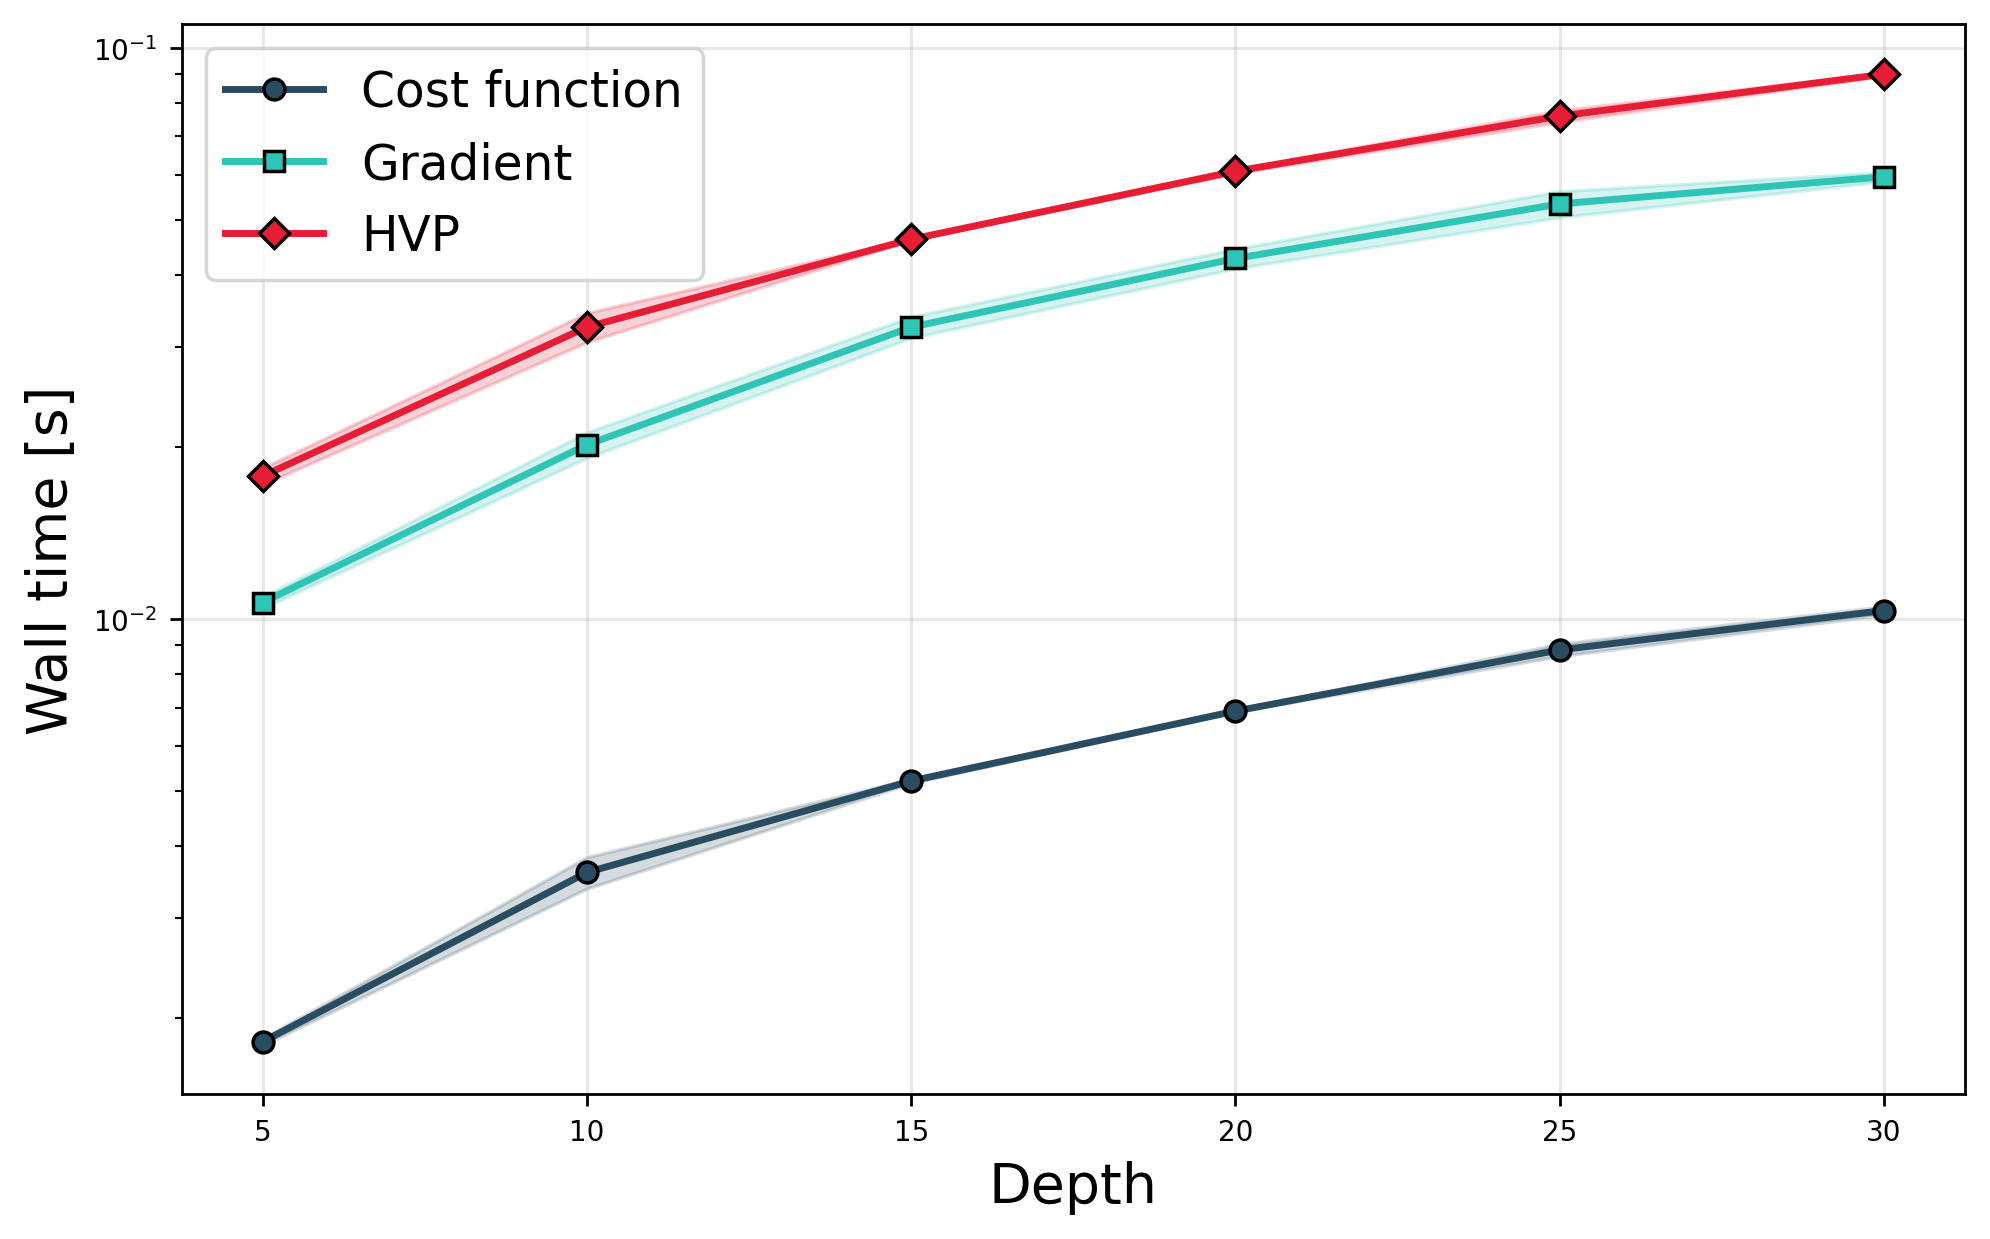

In [157]:
plot_wall_time(
    time_data=wall_times_depths, 
    x_values=depth_list,
    xlabel="Depth", 
    logscale="y",
    title=None, 
    label_fontsize=16, 
    legend_fontsize=14, 
    legend_loc="upper left"
)

In [92]:
cost_fn_times_depths = [time[0] for time in tuples_cost_depths]
wall_times_depths_2 = {
    r"Gradient": tuples_grads_depths,
    r"HVP": tuples_hvp_depths,
}

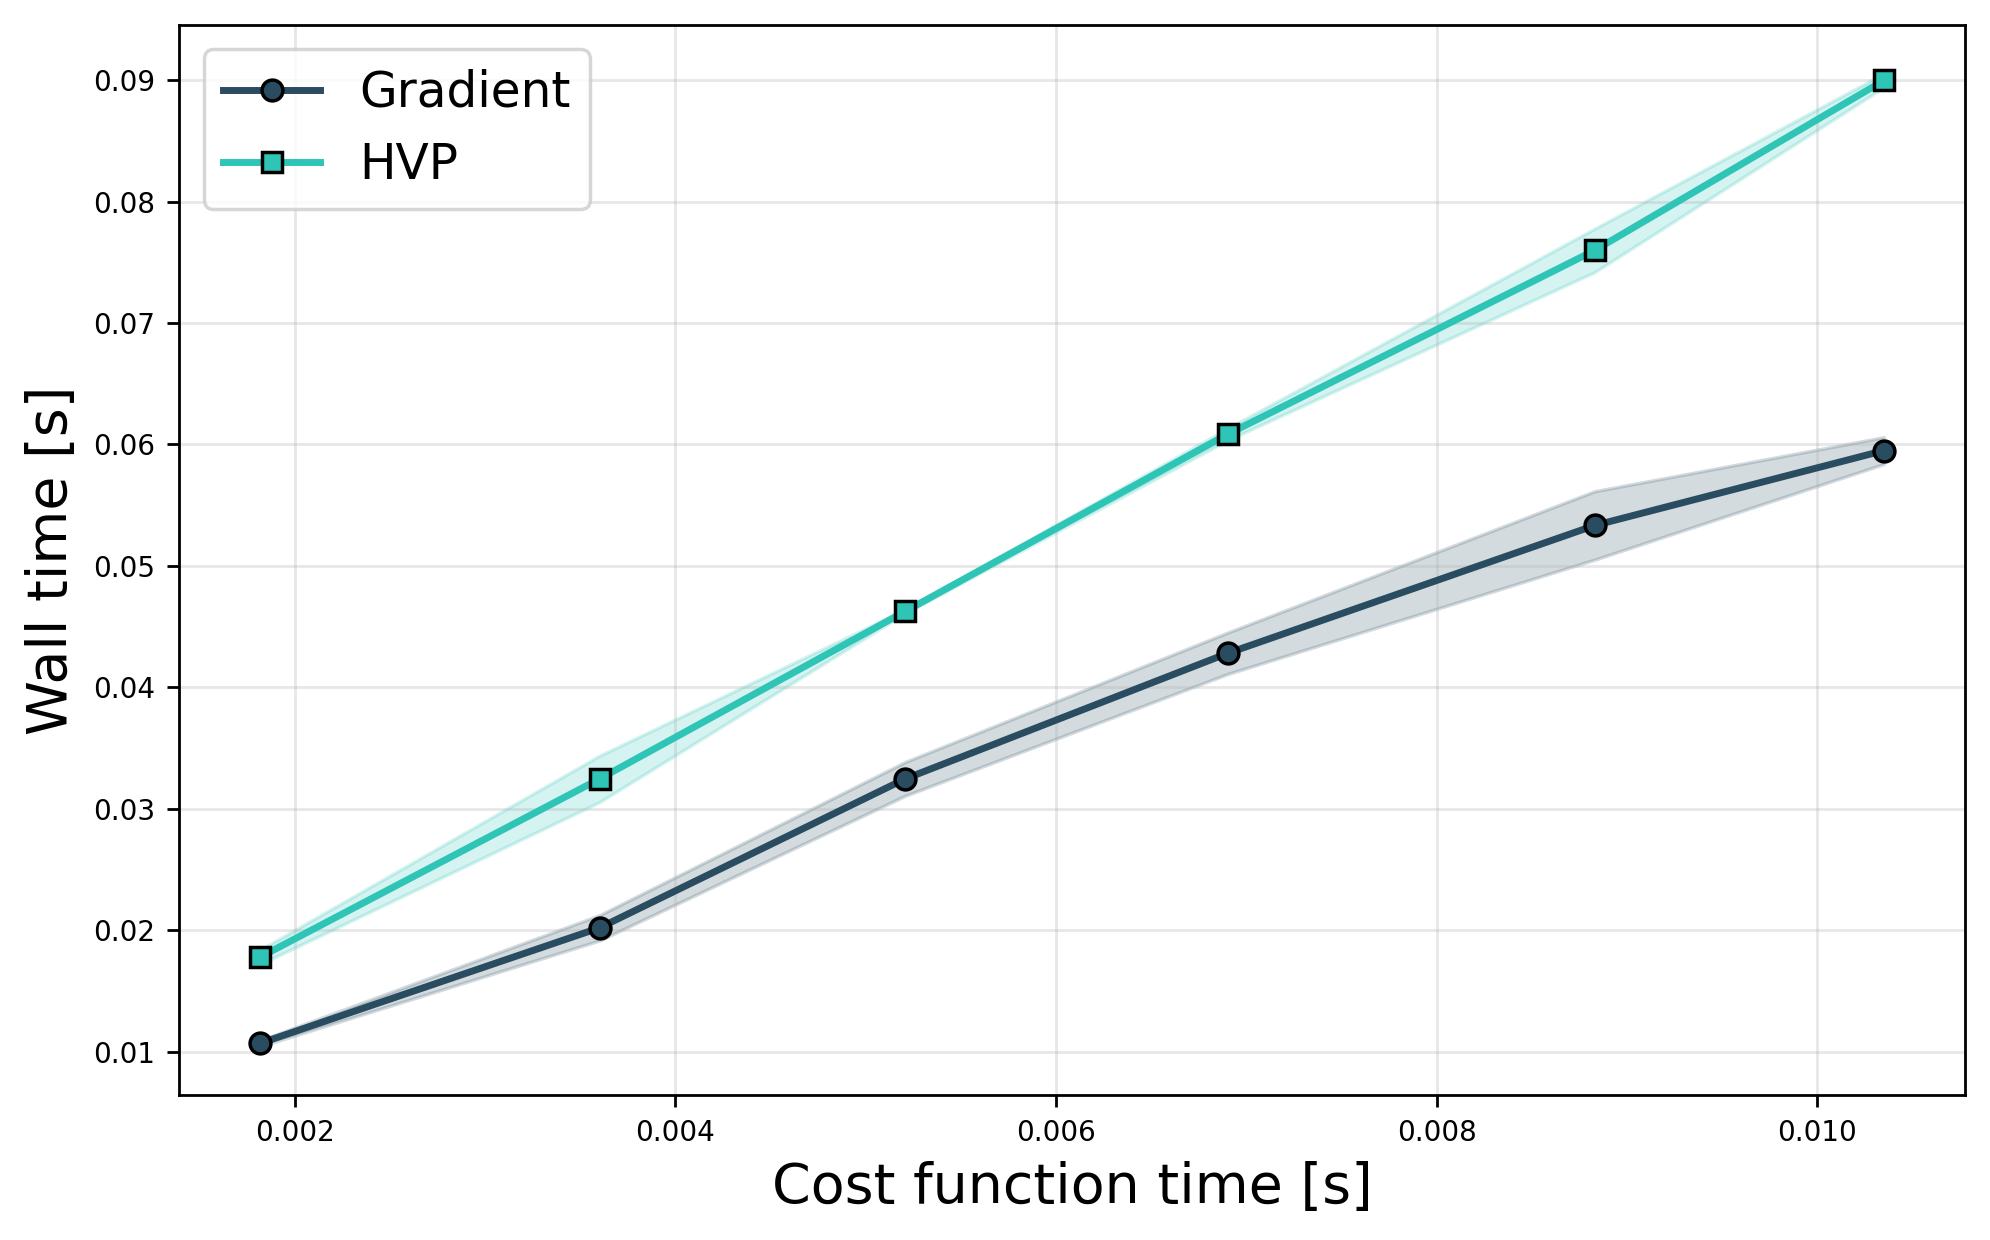

In [150]:
plot_wall_time(
    time_data=wall_times_depths_2, 
    x_values=cost_fn_times_depths,
    xlabel="Cost function time [s]", 
    logscale=None,
    title=None, 
    label_fontsize=16, 
    legend_fontsize=14, 
    legend_loc="upper left"
)

# Same procedure vs depth but now JIT:

### Timing

In [97]:
# Define jit compiled function and run it once to trigger compilation
cost_fn_jit = jax.jit(contract_mps_general_povm)

In [98]:
%time cost_fn_jit(**tensors_depths[0])

CPU times: user 212 μs, sys: 85 μs, total: 297 μs
Wall time: 157 μs


Array([1.06894542e+11+4.83198138e-07j], dtype=complex128)

In [96]:
%time cost_fn_jit(**tensors_depths[1])

CPU times: user 270 ms, sys: 12 ms, total: 282 ms
Wall time: 92.6 ms


Array([4.2115379e+21+13588.46945673j], dtype=complex128)

In [99]:
%time cost_fn_jit(**tensors_depths[2])

CPU times: user 327 ms, sys: 11.5 ms, total: 338 ms
Wall time: 114 ms


Array([1.31982772e+32+2.11302731e+15j], dtype=complex128)

In [100]:
%time cost_fn_jit(**tensors_depths[3])

CPU times: user 367 ms, sys: 11.1 ms, total: 378 ms
Wall time: 125 ms


Array([7.36220009e+42-1.01326783e+26j], dtype=complex128)

In [101]:
%time cost_fn_jit(**tensors_depths[4])

CPU times: user 425 ms, sys: 12 ms, total: 437 ms
Wall time: 145 ms


Array([2.05434249e+53+1.69133969e+36j], dtype=complex128)

In [102]:
%time cost_fn_jit(**tensors_depths[5])

CPU times: user 679 ms, sys: 94.8 ms, total: 774 ms
Wall time: 431 ms


Array([7.60509203e+63+8.92002303e+46j], dtype=complex128)

### Data generation

In [103]:
# Obtain a list of tensors depths without the kraus tensor
tensors_depths_no_kraus = []
for tensors in tensors_depths:
    tensors_no_kraus = {key: value for key, value in tensors.items() if key != "kraus_tensor"}
    tensors_depths_no_kraus.append(tensors_no_kraus)

In [107]:
tensors_depths[0].keys()

dict_keys(['kraus_tensor', 'povm_psd', 'state_psd', 'gates_indices'])

In [117]:
cost_fn_depth_5_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[0]).sum().real
cost_fn_depth_10_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[1]).sum().real
cost_fn_depth_15_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[2]).sum().real
cost_fn_depth_20_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[3]).sum().real
cost_fn_depth_25_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[4]).sum().real
cost_fn_depth_30_jit = lambda x: cost_fn_jit(kraus_tensor=x, **tensors_depths_no_kraus[5]).sum().real

In [118]:
grad_fn_depth_5_jit = automatic_gradient(cost_fn_depth_5_jit)
grad_fn_depth_10_jit = automatic_gradient(cost_fn_depth_10_jit)
grad_fn_depth_15_jit = automatic_gradient(cost_fn_depth_15_jit)
grad_fn_depth_20_jit = automatic_gradient(cost_fn_depth_20_jit)
grad_fn_depth_25_jit = automatic_gradient(cost_fn_depth_25_jit)
grad_fn_depth_30_jit = automatic_gradient(cost_fn_depth_30_jit)

### Compilation

In [119]:
%time grad_fn_depth_5_jit(kraus_tensor_fixed)

CPU times: user 337 ms, sys: 53.9 ms, total: 391 ms
Wall time: 168 ms


Array([[[[1.28188563e+09-1.28188563e+09j,
          1.34247546e+09-1.34247546e+09j,
          1.30116465e+09-1.30116465e+09j,
          1.51144370e+09-1.51144370e+09j],
         [1.11746340e+09-1.11746340e+09j,
          1.17028162e+09-1.17028162e+09j,
          1.13426957e+09-1.13426957e+09j,
          1.31757699e+09-1.31757699e+09j],
         [4.94268946e+08-4.94268946e+08j,
          5.17631147e+08-5.17631147e+08j,
          5.01702540e+08-5.01702540e+08j,
          5.82781852e+08-5.82781852e+08j],
         [4.49445687e+08-4.49445687e+08j,
          4.70689264e+08-4.70689264e+08j,
          4.56205158e+08-4.56205158e+08j,
          5.29931714e+08-5.29931714e+08j]],

        [[6.39967944e+08-6.39967944e+08j,
          6.77439774e+08-6.77439774e+08j,
          6.39056375e+08-6.39056375e+08j,
          7.45136824e+08-7.45136824e+08j],
         [5.57881870e+08-5.57881870e+08j,
          5.90547341e+08-5.90547341e+08j,
          5.57087224e+08-5.57087224e+08j,
          6.49561167e+08-6.

In [121]:
%time grad_10_jit = grad_fn_depth_10_jit(kraus_tensor_fixed)

CPU times: user 556 ms, sys: 53.3 ms, total: 610 ms
Wall time: 246 ms


In [122]:
%time grad_15_jit = grad_fn_depth_15_jit(kraus_tensor_fixed)

CPU times: user 712 ms, sys: 24.5 ms, total: 736 ms
Wall time: 255 ms


In [123]:
%time grad_20_jit = grad_fn_depth_20_jit(kraus_tensor_fixed)

CPU times: user 903 ms, sys: 28.9 ms, total: 932 ms
Wall time: 322 ms


In [124]:
%time grad_25_jit = grad_fn_depth_25_jit(kraus_tensor_fixed)

CPU times: user 1.22 s, sys: 106 ms, total: 1.32 s
Wall time: 640 ms


In [125]:
%time grad_30_jit = grad_fn_depth_30_jit(kraus_tensor_fixed)

CPU times: user 1.2 s, sys: 24.6 ms, total: 1.23 s
Wall time: 420 ms


In [129]:
%time hvp_jit_5 = hvp(function=grad_fn_depth_5_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 549 ms, sys: 325 ms, total: 874 ms
Wall time: 578 ms


In [130]:
%time hvp_jit_10 = hvp(function=grad_fn_depth_10_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 917 ms, sys: 41.2 ms, total: 958 ms
Wall time: 294 ms


In [132]:
%time hvp_jit_15 = hvp(function=grad_fn_depth_15_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 1.28 s, sys: 69.8 ms, total: 1.35 s
Wall time: 436 ms


In [133]:
%time hvp_jit_20 = hvp(function=grad_fn_depth_20_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 1.6 s, sys: 47.1 ms, total: 1.65 s
Wall time: 510 ms


In [134]:
%time hvp_jit_25 = hvp(function=grad_fn_depth_25_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 2.19 s, sys: 60.9 ms, total: 2.25 s
Wall time: 784 ms


In [135]:
%time hvp_jit_30 = hvp(function=grad_fn_depth_30_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)

CPU times: user 2.39 s, sys: 57.3 ms, total: 2.45 s
Wall time: 800 ms


### Timing

In [ ]:
timing_cost_jit_depth0 = %timeit -o cost_fn_depth_5_jit(kraus_tensor_fixed)
timing_cost_jit_depth1 = %timeit -o cost_fn_depth_10_jit(kraus_tensor_fixed)
timing_cost_jit_depth2 = %timeit -o cost_fn_depth_15_jit(kraus_tensor_fixed)
timing_cost_jit_depth3 = %timeit -o cost_fn_depth_20_jit(kraus_tensor_fixed)
timing_cost_jit_depth4 = %timeit -o cost_fn_depth_25_jit(kraus_tensor_fixed)
timing_cost_jit_depth5 = %timeit -o cost_fn_depth_30_jit(kraus_tensor_fixed)

23.1 μs ± 196 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
38.2 μs ± 1.51 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
57.2 μs ± 144 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
68.4 μs ± 1.67 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
79.1 μs ± 501 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
90.6 μs ± 233 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [126]:
timing_grad_jit_depth0 = %timeit -o grad_fn_depth_5_jit(kraus_tensor_fixed)
timing_grad_jit_depth1 = %timeit -o grad_fn_depth_10_jit(kraus_tensor_fixed)
timing_grad_jit_depth2 = %timeit -o grad_fn_depth_15_jit(kraus_tensor_fixed)
timing_grad_jit_depth3 = %timeit -o grad_fn_depth_20_jit(kraus_tensor_fixed)
timing_grad_jit_depth4 = %timeit -o grad_fn_depth_25_jit(kraus_tensor_fixed)
timing_grad_jit_depth5 = %timeit -o grad_fn_depth_30_jit(kraus_tensor_fixed)

1.03 ms ± 22.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.53 ms ± 48.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.91 ms ± 4.84 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.32 ms ± 22.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.74 ms ± 17.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3.16 ms ± 10.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [136]:
timing_hvp_jit_depth0 = %timeit -o hvp(function=grad_fn_depth_5_jit,  x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_jit_depth1 = %timeit -o hvp(function=grad_fn_depth_10_jit, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_jit_depth2 = %timeit -o hvp(function=grad_fn_depth_15_jit, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_jit_depth3 = %timeit -o hvp(function=grad_fn_depth_20_jit, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_jit_depth4 = %timeit -o hvp(function=grad_fn_depth_25_jit, x=kraus_tensor_fixed, z=kraus_tensor_fixed)
timing_hvp_jit_depth5 = %timeit -o hvp(function=grad_fn_depth_30_jit, x=kraus_tensor_fixed, z=kraus_tensor_fixed)

1.27 ms ± 15.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.88 ms ± 21 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.47 ms ± 11.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.99 ms ± 26.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3.66 ms ± 195 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.23 ms ± 196 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Plotting

In [140]:
timings_cost_depths_jit = [timing_cost_jit_depth0, timing_cost_jit_depth1, timing_cost_jit_depth2, timing_cost_jit_depth3, timing_cost_jit_depth4, timing_cost_jit_depth5]

timings_grad_depths_jit = [timing_grad_jit_depth0, timing_grad_jit_depth1, timing_grad_jit_depth2, timing_grad_jit_depth3, timing_grad_jit_depth4, timing_grad_jit_depth5]

timings_hvp_depths_jit = [timing_hvp_jit_depth0, timing_hvp_jit_depth1, timing_hvp_jit_depth2, timing_hvp_jit_depth3, timing_hvp_jit_depth4, timing_hvp_jit_depth5]

tuples_cost_depths_jit = [(time.average, time.stdev) for time in timings_cost_depths_jit]
tuples_grad_depths_jit = [(time.average, time.stdev) for time in timings_grad_depths_jit]
tuples_hvp_depths_jit = [(time.average, time.stdev) for time in timings_hvp_depths_jit]

wall_times_depths_unjit_and_jit = {
    "Cost function": tuples_cost_depths,
    "Gradient": tuples_grads_depths,
    "HVP": tuples_hvp_depths,
    "Cost function (JIT)": tuples_cost_depths_jit,
    "Gradient (JIT)": tuples_grad_depths_jit,
    "HVP (JIT)": tuples_hvp_depths_jit}

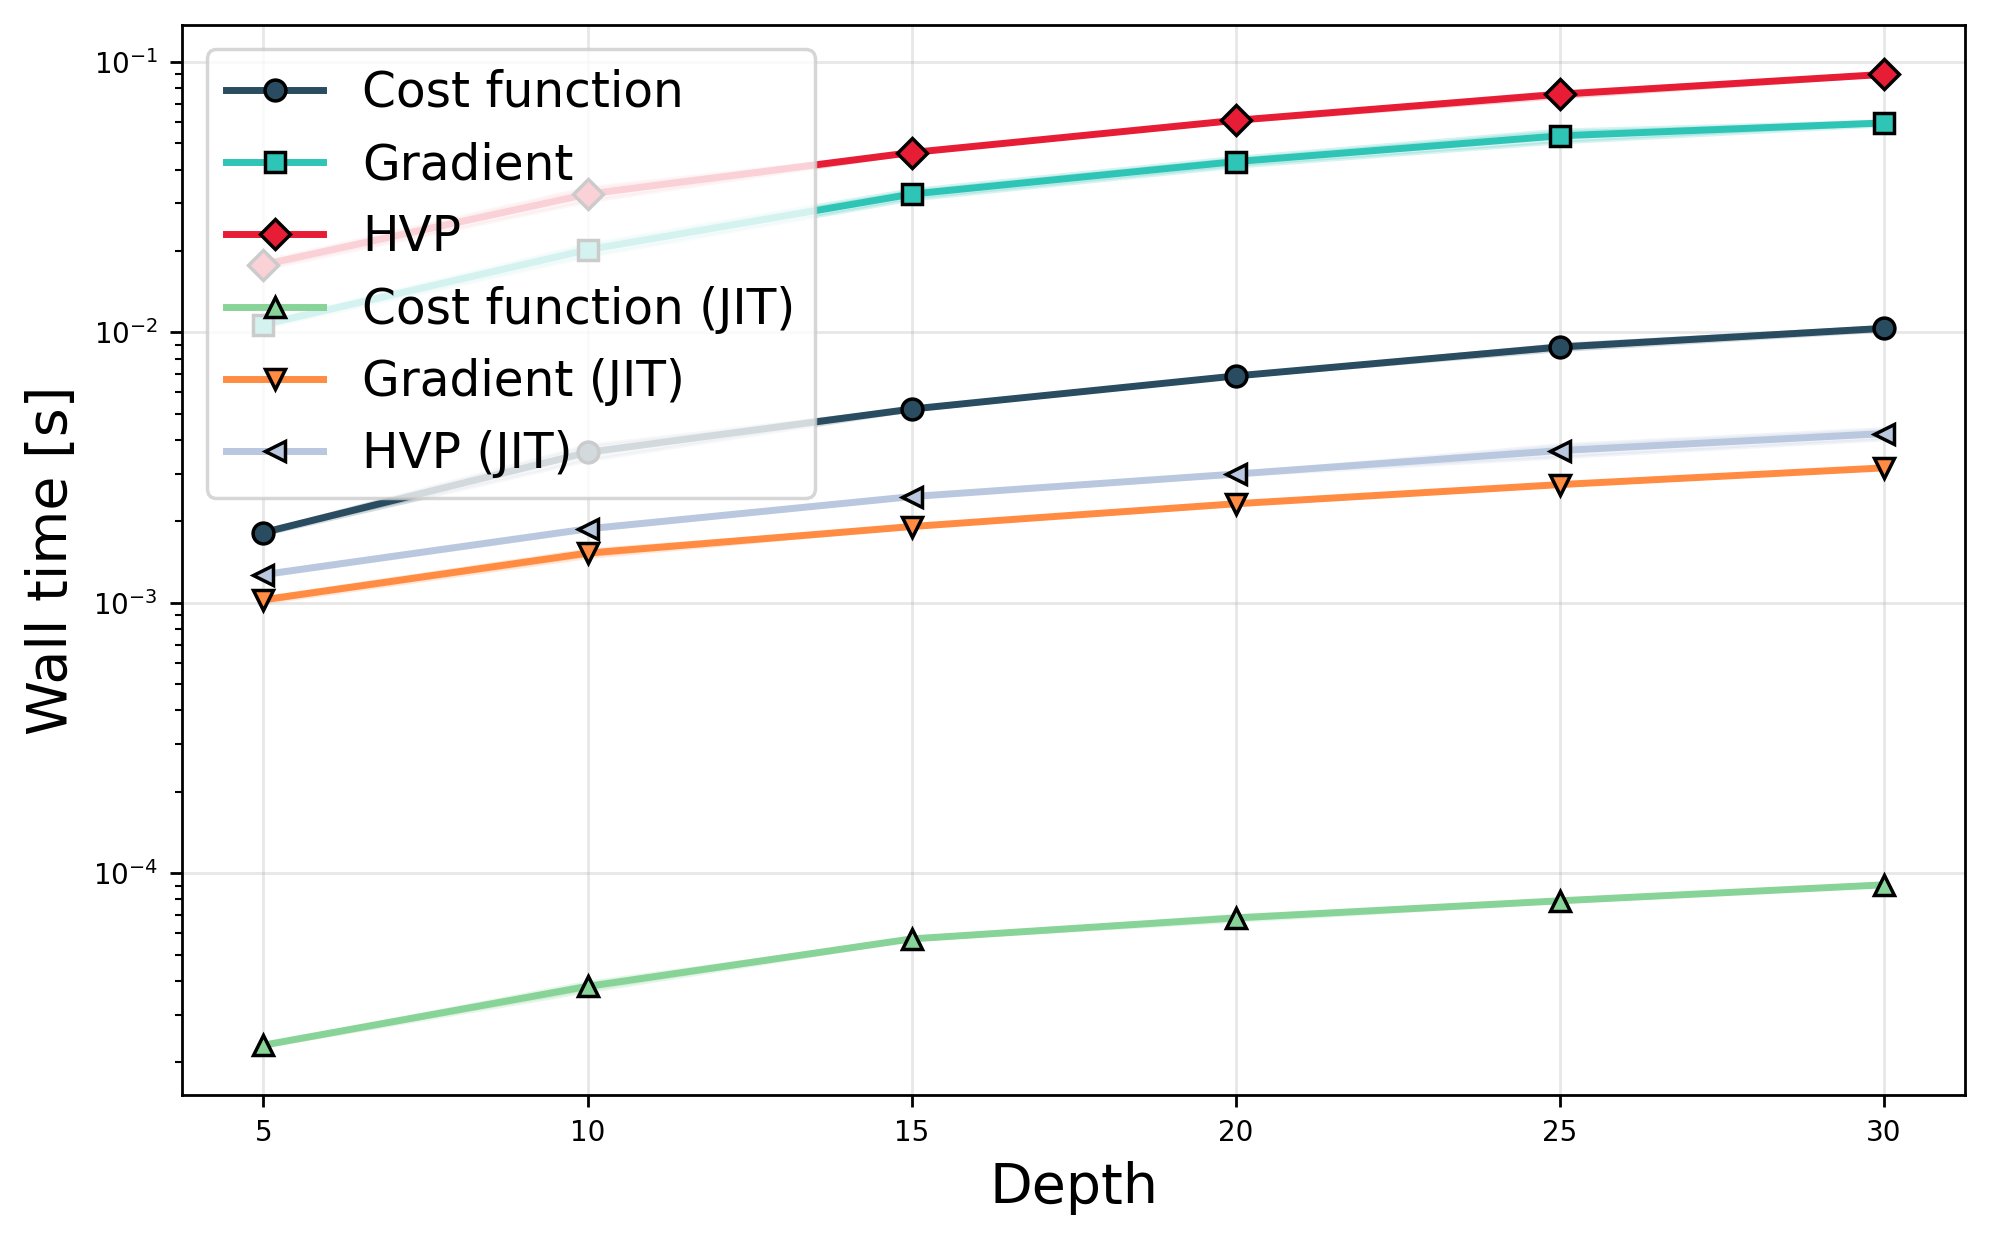

In [156]:
plot_wall_time(
    time_data=wall_times_depths_unjit_and_jit, 
    x_values=depth_list,
    xlabel="Depth", 
    logscale="y",
    title=None, 
    label_fontsize=16, 
    legend_fontsize=14, 
    legend_loc="upper left"
)

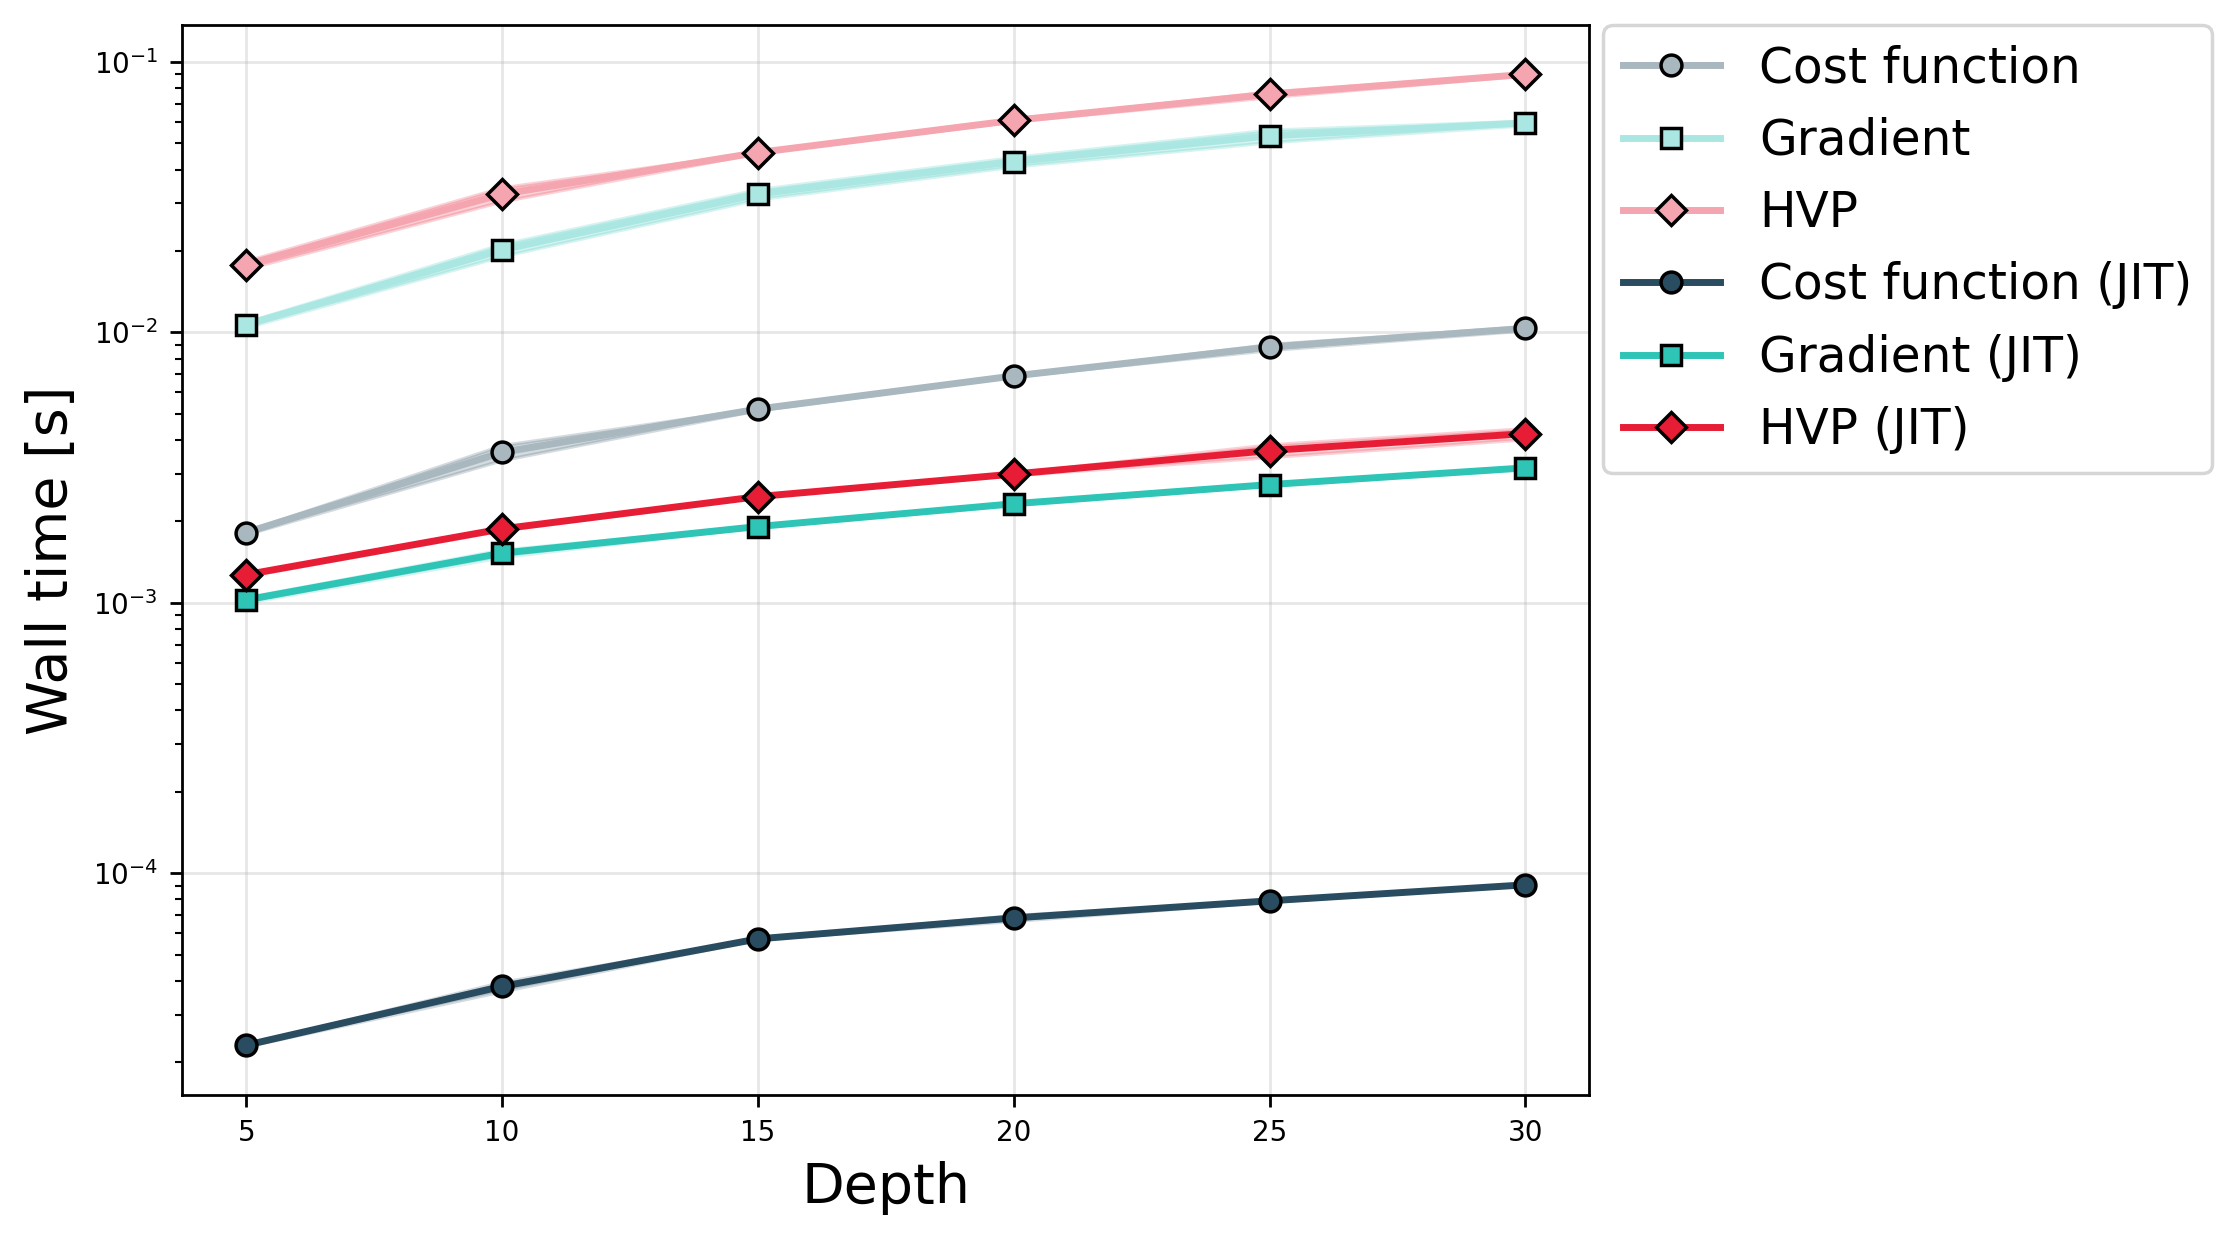

In [181]:
wall_times_depths_unjit = {
    "Cost function": tuples_cost_depths,
    "Gradient": tuples_grads_depths,
    "HVP": tuples_hvp_depths,
   }
wall_times_depths_jit = {
    "Cost function (JIT)": tuples_cost_depths_jit,
    "Gradient (JIT)": tuples_grad_depths_jit,
    "HVP (JIT)": tuples_hvp_depths_jit
}
wall_times_list = [wall_times_depths_unjit, wall_times_depths_jit]
plot_many_sets_wall_time(
    time_data_sets=wall_times_list,
    x_values=depth_list,
    xlabel="Depth",
    logscale="y",
    title=None,
    label_fontsize=16,
    legend_fontsize=14,
)

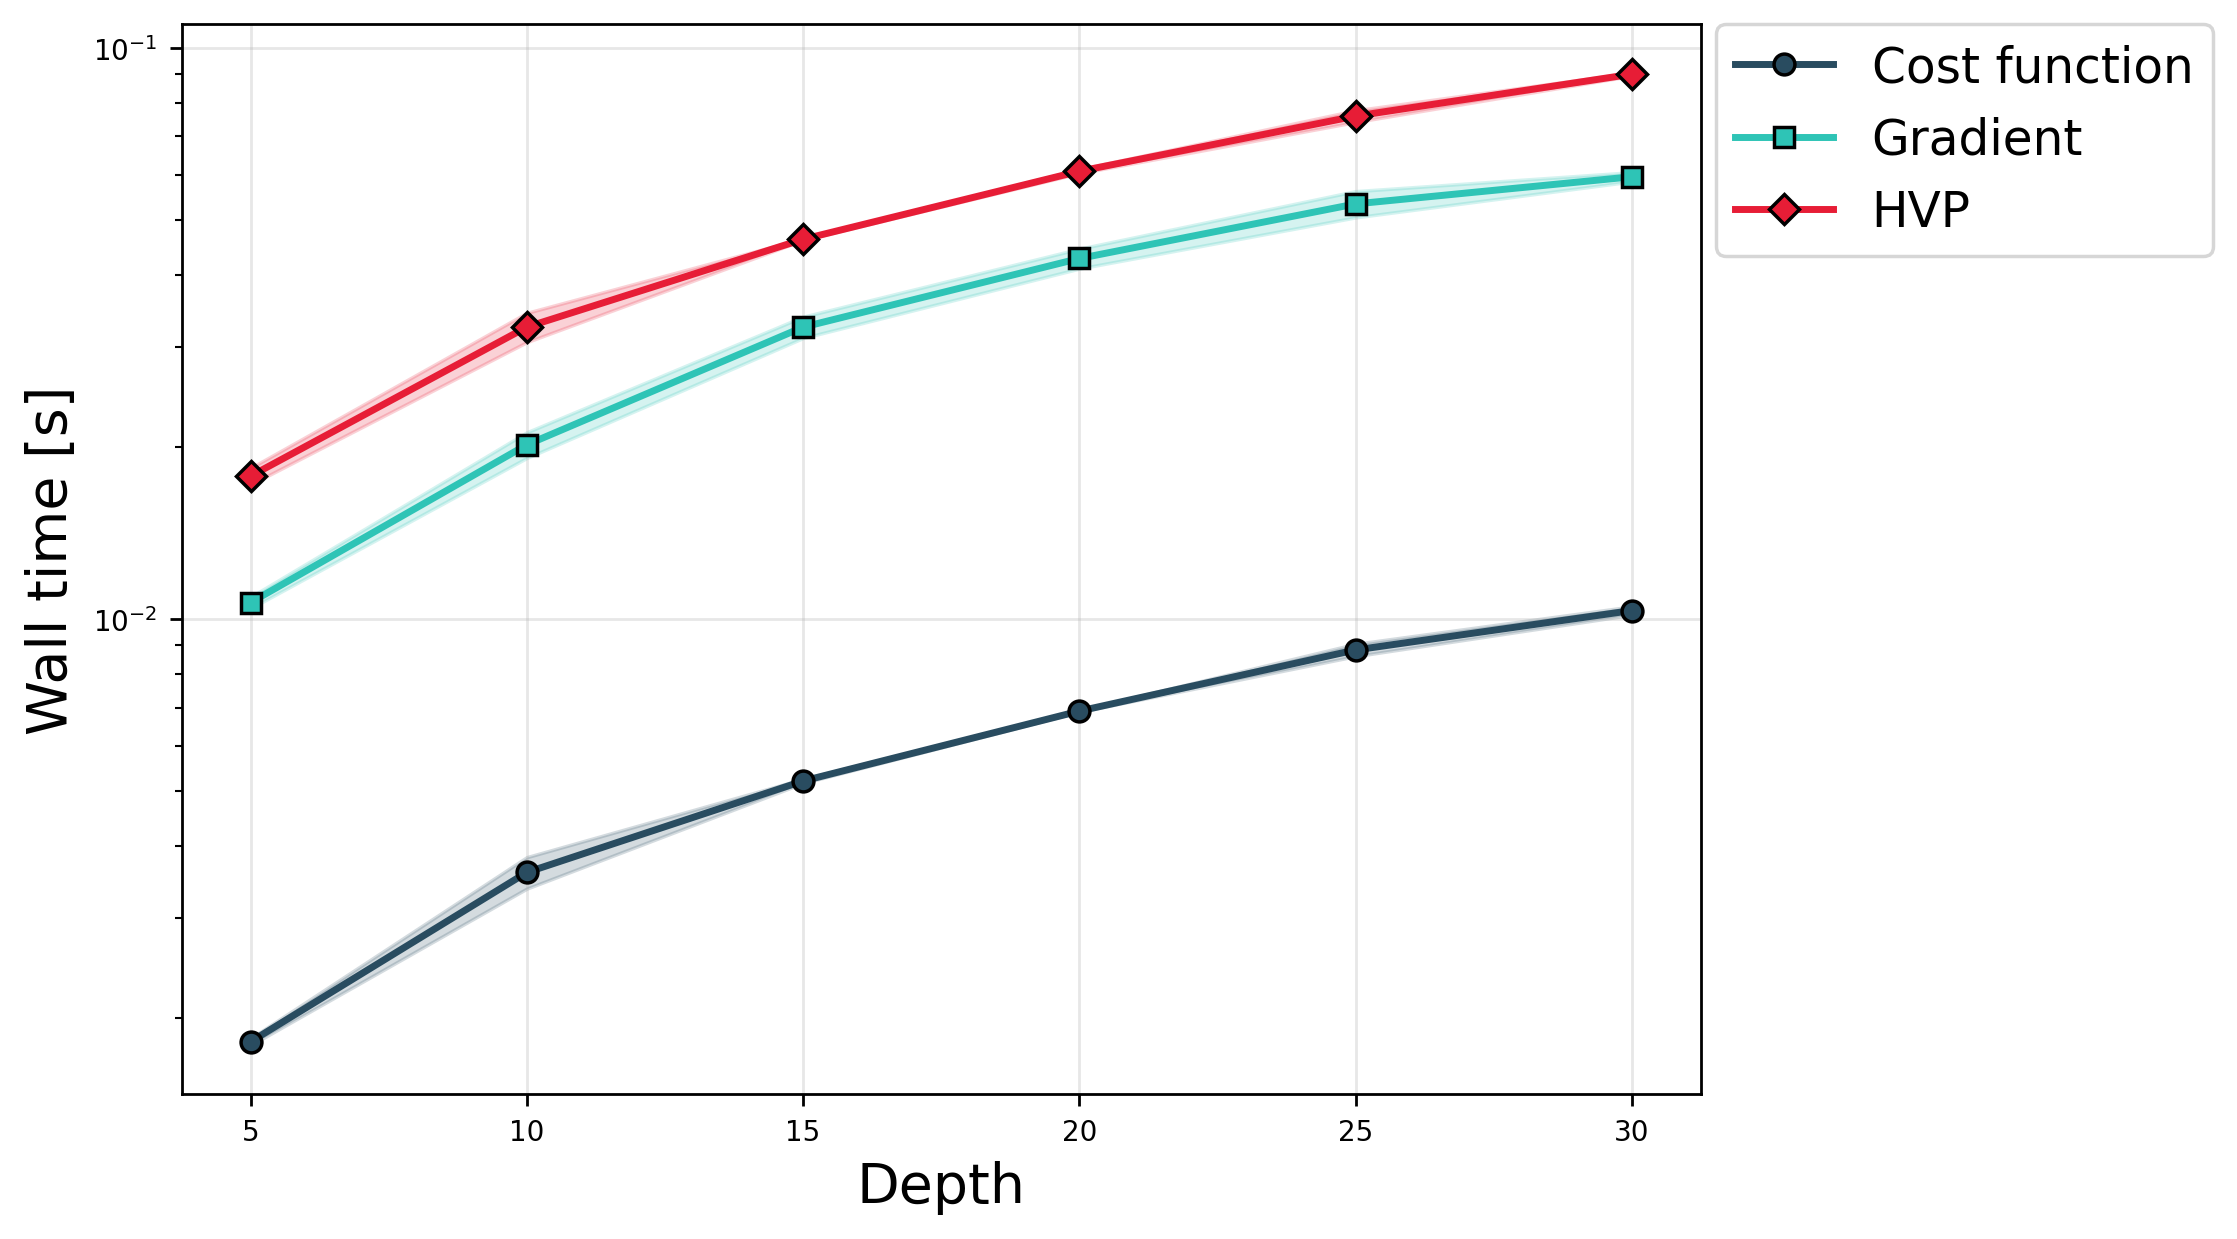

In [180]:
plot_many_sets_wall_time(
    time_data_sets=[wall_times_depths_unjit],
    x_values=depth_list,
    xlabel="Depth",
    logscale="y",
    title=None,
    label_fontsize=16,
    legend_fontsize=14,
)